In [113]:
# Import Libraries
import pandas as pd
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
import pickle

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Sklearn and Imbalanced-learn Libraries
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler 
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFECV, VarianceThreshold, mutual_info_classif
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, balanced_accuracy_score,
    classification_report
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils import resample
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE




from sklearn.base import BaseEstimator, TransformerMixin

# Additional Libraries
from sklearn.base import clone
from sklearn.exceptions import NotFittedError
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries with GPU Support
import xgboost as xgb
import lightgbm as lgb

# For SHAP values
import shap

# Statistical Tests
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

# For progress monitoring
from tqdm import tqdm
from kneed import KneeLocator


import warnings

# Suppress warnings to reduce clutter
warnings.filterwarnings('ignore')

from sklearn.exceptions import ConvergenceWarning

# Suppress ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from joblib import Parallel, delayed
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

# Necessary imports
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import cross_val_score
from sklearn.utils.validation import check_X_y, check_array
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
import numpy as np



In [114]:
# File paths for clinical, extracted features and radiomics features
clinical_data_path = '/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/Clinical_and_Other_Features_final_comb.xlsx'
#features_path = '/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/features_extracted_VGG19_tumor_mid10_5_augmented_bal_1.pkl.gz'
features_path = '/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/features_extracted_VGG16_tumor_mid10_5_augmented_bal_1.pkl.gz' 
#features_path = '/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/features_extracted_ViT_tumor_mid10_5_augmented_bal_1.pkl.gz'
test_features_path = '/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/features_extracted_VGG16_tumor_mid10_5_augmented_fixed.pkl.gz'
#features_path = '/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/features_vgg16_late_60_40_ratio.pkl.gz'
#features_path = '/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/features_extracted_VGG16_tumor_mid10_5_augmented_fixed.pkl.gz' 
#imaging_features_path = '/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/Imaging_Features.xlsx'

In [115]:
#Function: Load and Process Clinical and Extracted Features Data
def load_clinical_data(clinical_data_path):
    """
    Loads and preprocesses clinical data from an Excel file.

    Parameters:
    - clinical_data_path (str): Path to the clinical data Excel file.

    Returns:
    - pd.DataFrame: Preprocessed clinical data.
    """
    print("Loading clinical data...")
    clinical_data = pd.read_excel(clinical_data_path)

    # Rename columns for consistency
    clinical_data.columns = [col.replace(' ', '_') for col in clinical_data.columns]
    clinical_data = clinical_data.rename(
        columns={
            'Patient_ID': 'patient_id',
            'Pathologic_Response_to_Neoadjuvant_Therapy': 'response'
        }
    )

    # Convert 'Breast_MRI_001' to '001' in the patient_id column
    clinical_data['patient_id'] = clinical_data['patient_id'].apply(
        lambda x: x.split('_')[-1] if isinstance(x, str) else x
    )

    # Convert response to binary: 1 means pCR, else non-pCR
    clinical_data['response'] = clinical_data['response'].apply(
        lambda x: 1 if x == 1 else 0
    )

    # Preprocess clinical data
    clinical_data['patient_id'] = clinical_data['patient_id'].astype(str)

    # Separate numerical and categorical columns
    patient_id_cols = ["patient_id"]
    response_cols = ["response"]
    numerical_cols = ["Date_of_Birth"]  # Consider converting to 'Age at Diagnosis'
    categorical_cols = clinical_data.columns[
        (clinical_data.columns != "Date_of_Birth") &
        (clinical_data.columns != "patient_id") &
        (clinical_data.columns != "response")
    ]

    numerical_df = clinical_data[numerical_cols]
    patient_id_df = clinical_data[patient_id_cols]
    response_df = clinical_data[response_cols]

    # One-hot encode categorical columns
    clinical_data[categorical_cols] = clinical_data[categorical_cols].astype('category')
    categorical_df = pd.get_dummies(clinical_data[categorical_cols], drop_first=True)
    categorical_df = categorical_df.astype(int)

    # Concatenate all dataframes
    encoded_df = pd.concat(
        [patient_id_df, numerical_df, categorical_df, response_df],
        axis=1
    )

    print("Clinical data loaded and processed.")
    return encoded_df

#def load_image_features(features_path):
#    """
#    Loads and processes image features from a compressed pickle file.
#
#    Parameters:
#    - features_path (str): Path to the compressed pickle file containing image features.
#
#    Returns:
#    - pd.DataFrame: Processed image features.
#    """
#    print("Loading image features...")
#    with gzip.open(features_path, 'rb') as f:
#        features_dict = pickle.load(f)
#
#    # Extract patient IDs and features
#    features_data = {
#        'patient_id': [key.split('-')[0] for key in features_dict.keys()],
#        **{
#            f'feature_{i}': [features_dict[key][i] for key in features_dict.keys()]
#            for i in range(len(next(iter(features_dict.values()))))
#        }
#    }
#
#    # Create a DataFrame
#    features_df = pd.DataFrame(features_data)
#    features_df['patient_id'] = features_df['patient_id'].astype(str)
#    print("Image features loaded.")
#    return features_df

def load_image_features(features_path): 
    print("Loading image features...") 
    with gzip.open(features_path, 'rb') as f:
        features_dict = pickle.load(f) # Extract patient id and augmentation id from each key (e.g., "265-108_0")
        features_data = {
            'patient_id': [key.split('-')[0] for key in features_dict.keys()],
            'aug_id': [key.split('_')[-1] for key in features_dict.keys()],
            **{
                f'feature_{i}': [features_dict[key][i] for key in features_dict.keys()]
                for i in range(len(next(iter(features_dict.values()))))
            }
        }
        
        features_df = pd.DataFrame(features_data)
        features_df['patient_id'] = features_df['patient_id'].astype(str)
        print("Image features loaded.")
        return features_df


def load_and_preprocess_data(clinical_data_path, features_path):
    clinical_data_processed = load_clinical_data(clinical_data_path)
    features_df = load_image_features(features_path) # This function should now return columns: patient_id, aug_id, feature_0, feature_1, ...
    clinical_data_processed['patient_id'] = clinical_data_processed['patient_id'].astype(str)
    features_df['patient_id'] = features_df['patient_id'].astype(str)

    print("Preparing dataset variations...")

    datasets = {}

    # Identify feature columns (do not include meta columns: patient_id, aug_id)
    feature_cols = [col for col in features_df.columns if col.startswith('feature_')]

    # Impute missing values on feature columns only
    print("Imputing missing values in image features...")
    
    imputer = SimpleImputer(strategy='mean')
    features_imputed = imputer.fit_transform(features_df[feature_cols])

    # Scale the imputed features
    print("Scaling image features...")
    
    scaler = MinMaxScaler()
    features_scaled = scaler.fit_transform(features_imputed)
    features_scaled_df = pd.DataFrame(features_scaled, columns=feature_cols)
    # Add back the meta columns
    features_scaled_df['patient_id'] = features_df['patient_id'].values
    features_scaled_df['aug_id'] = features_df['aug_id'].values

    # Merge the scaled image features with clinical data on patient_id
    data_scaled = features_scaled_df.merge(
        clinical_data_processed,
        on='patient_id',
        how='inner'
    ).reset_index(drop=True)

    # 1. Image Features (Scaled)
    # Retain only the feature columns for modeling; meta information will be kept separately for filtering later.
    image_feature_columns = [col for col in data_scaled.columns if 'feature_' in col]
    X_image = data_scaled[image_feature_columns].copy()
    y_image = data_scaled['response'].astype(int)
    # Save meta information (patient_id and aug_id) for later filtering of test/validation sets
    groups_image = data_scaled['patient_id']
    meta_image = data_scaled[['patient_id', 'aug_id']].copy()


    # 2. Clinical Features
    patient_ids_in_data_scaled = clinical_data_processed['patient_id'].isin(data_scaled['patient_id'])
    clinical_data_in_data_scaled = clinical_data_processed[patient_ids_in_data_scaled].reset_index(drop=True)
    X_clinical = clinical_data_in_data_scaled.drop(columns=['patient_id', 'response'])
    y_clinical = clinical_data_in_data_scaled['response'].astype(int)
    groups_clinical = clinical_data_in_data_scaled['patient_id']

    # 3. Combined Features (Scaled image features + clinical data)
    # Remove meta columns so that only feature data is used.
    exclude_columns = ['patient_id', 'response', 'aug_id']
    X_combined = data_scaled.drop(columns=exclude_columns)
    y_combined = data_scaled['response'].astype(int)
    groups_combined = data_scaled['patient_id']
    meta_combined = data_scaled[['patient_id', 'aug_id']].copy()



    # Optional: Preprocess each dataset variation (e.g. remove features with zero variance)
    

    def preprocess_data(X):
        variance_threshold = VarianceThreshold(threshold=0)
        X_var = variance_threshold.fit_transform(X)
        feature_names = X.columns[variance_threshold.get_support(indices=True)]
        return pd.DataFrame(X_var, columns=feature_names)

    X_combined = preprocess_data(X_combined)
    X_clinical = preprocess_data(X_clinical)
    X_image = preprocess_data(X_image)

    datasets['Combined'] = (X_combined, y_combined, groups_combined, meta_combined)
    datasets['Clinical'] = (X_clinical, y_clinical, groups_clinical)
    datasets['Image'] = (X_image, y_image,groups_image, meta_image)

    return datasets

In [116]:
# features path contains images where the augmentation was done class aware to equalize the classes making them close to 50-50%. this data will only be used for training data
# Make Clinical, Image and Combined Data in data variations
data_variations = load_and_preprocess_data(clinical_data_path, features_path)

Loading clinical data...
Clinical data loaded and processed.
Loading image features...
Image features loaded.
Preparing dataset variations...
Imputing missing values in image features...
Scaling image features...


In [117]:
# test features path contains data set where the augmentation of images done differently - that is not target class aware, that is all images equally augmented
# taking the test set from this data set
data_variations_test = load_and_preprocess_data(clinical_data_path, test_features_path)

Loading clinical data...
Clinical data loaded and processed.
Loading image features...
Image features loaded.
Preparing dataset variations...
Imputing missing values in image features...
Scaling image features...


In [118]:
##Function: Load additional imaging features from radiomics Imaging_Features.xlsx
#
#def load_additional_imaging_features(imaging_features_path):
#    print("Loading additional imaging features...")
#    imaging_features_df = pd.read_excel(imaging_features_path)
#    
#    # Rename the 'Patient ID' column to 'patient_id'
#    imaging_features_df = imaging_features_df.rename(columns={'Patient ID': 'patient_id'})
#    
#    # Convert 'Breast_MRI_001' to '001' in the patient_id column
#    imaging_features_df['patient_id'] = imaging_features_df['patient_id'].apply(
#        lambda x: x.split('_')[-1] if isinstance(x, str) else x
#    )
#    
#    # Ensure patient_id is string type
#    imaging_features_df['patient_id'] = imaging_features_df['patient_id'].astype(str)
#    
#    # Clean up feature names by replacing spaces and special characters
#    imaging_features_df.columns = [col.replace(' ', '_')
#                                     .replace('(', '')
#                                     .replace(')', '')
#                                     .replace(',', '_')
#                                     .replace('.', '_') for col in imaging_features_df.columns]
#    
#    print("Additional imaging features loaded.")
#    return imaging_features_df
#
## Load the additional imaging features
#additional_imaging_features_df = load_additional_imaging_features(imaging_features_path)


In [119]:
## Prepare new datasets with the radiomics imaging features
#
#print("Preparing new datasets with additional imaging features...")
#
#clinical_data_processed = load_clinical_data(clinical_data_path)
## Ensure patient IDs are strings
#additional_imaging_features_df['patient_id'] = additional_imaging_features_df['patient_id'].astype(str)
#clinical_data_processed['patient_id'] = clinical_data_processed['patient_id'].astype(str)
#
## Imaging Only Dataset (from Imaging_Features.xlsx)
## Merge the imaging features with the response variable from clinical data
#imaging_only_df = additional_imaging_features_df.merge(
#    clinical_data_processed[['patient_id', 'response']],
#    on='patient_id',
#    how='inner'
#)
#
## Create X and y for Imaging Only dataset
#X_imaging_only = imaging_only_df.drop(columns=['patient_id', 'response'])
#y_imaging_only = imaging_only_df['response'].astype(int)
#groups_imaging_only = imaging_only_df['patient_id']
#
## Clinical + Imaging Dataset
## Merge imaging features with clinical data
#clinical_imaging_df = additional_imaging_features_df.merge(
#    clinical_data_processed,
#    on='patient_id',
#    how='inner'
#)
#
## Create X and y for Clinical + Imaging dataset
#X_clinical_imaging = clinical_imaging_df.drop(columns=['patient_id', 'response'])
#y_clinical_imaging = clinical_imaging_df['response'].astype(int)
#groups_clinical_imaging = clinical_imaging_df['patient_id']
#
## Combined Existing Dataset + Imaging Features (Extracted Features + Clinical + Imaging)
## Get existing combined dataset
#X_combined_existing, y_combined_existing, groups_combined_existing = data_variations['Combined']
#
## Ensure patient IDs are strings
#X_combined_existing = X_combined_existing.copy()
#X_combined_existing['patient_id'] = groups_combined_existing.astype(str)
#
## Merge with additional imaging features
#combined_with_imaging_df = X_combined_existing.merge(
#    additional_imaging_features_df,
#    on='patient_id',
#    how='inner'
#)
#
## Ensure response variable is included
#combined_with_imaging_df = combined_with_imaging_df.merge(
#    clinical_data_processed[['patient_id', 'response']],
#    on='patient_id',
#    how='left'
#)
#
## Create X and y for Combined with Imaging dataset
#X_combined_with_imaging = combined_with_imaging_df.drop(columns=['patient_id', 'response'])
#y_combined_with_imaging = combined_with_imaging_df['response'].astype(int)
#groups_combined_with_imaging = combined_with_imaging_df['patient_id']
#
## Add new datasets to data_variations
#data_variations['RadiomicsOnly'] = (X_imaging_only, y_imaging_only, groups_imaging_only)
#data_variations['ClinicalRadiomics'] = (X_clinical_imaging, y_clinical_imaging, groups_clinical_imaging)
#data_variations['CombinedRadiomics'] = (X_combined_with_imaging, y_combined_with_imaging, groups_combined_with_imaging)
#
#print("New datasets added to data_variations.")


In [120]:
# #Data Train Test Split
# def stratified_group_split(X, y, groups, test_size=0.3, random_state=None):
#     # Create a DataFrame with groups and their corresponding class labels
#     group_df = pd.DataFrame({'group': groups, 'label': y})
#     group_df = group_df.drop_duplicates()

#     # Perform stratified split on groups
#     stratify = group_df['label']
#     group_train, group_test = train_test_split(
#         group_df['group'], test_size=test_size, random_state=random_state, stratify=stratify
#     )

#     # Select samples based on group splits
#     train_idx = X[groups.isin(group_train)].index
#     test_idx = X[groups.isin(group_test)].index

#     return train_idx, test_idx



# # Usage
# data_splits = {}

# for dataset_name, data_tuple in data_variations.items():
#     # Unpack the tuple.
#     # If there are 4 elements, the last one is the meta DataFrame containing aug_id.
#     if len(data_tuple) == 3:
#         X_full, y_full, groups = data_tuple
#         meta_full = None
#     else:
#         X_full, y_full, groups, meta_full = data_tuple

#     # Reset indices for consistency
#     groups = pd.Series(groups).reset_index(drop=True)
#     y_full_series = pd.Series(y_full).reset_index(drop=True)
#     X_full = X_full.reset_index(drop=True)
#     if meta_full is not None:
#         meta_full = meta_full.reset_index(drop=True)

#     # Perform stratified group splitting
#     train_idx, test_idx = stratified_group_split(X_full, y_full_series, groups, test_size=0.3, random_state=42)
    
#     X_train_full = X_full.loc[train_idx].reset_index(drop=True)
#     y_train_full = y_full_series.loc[train_idx].reset_index(drop=True)
#     X_test_full = X_full.loc[test_idx].reset_index(drop=True)
#     y_test = y_full_series.loc[test_idx].reset_index(drop=True)
    
#     # If meta info exists (i.e. aug_id is stored externally), filter the test set using meta.
#     if meta_full is not None:
#         meta_test = meta_full.loc[test_idx].reset_index(drop=True)
#         original_mask = meta_test['aug_id'] == '0'
#         X_test_full = X_test_full.loc[original_mask].reset_index(drop=True)
#         y_test = y_test.loc[original_mask].reset_index(drop=True)

#     patient_ids_train = groups.loc[train_idx].reset_index(drop=True)
#     patient_ids_test = groups.loc[test_idx].reset_index(drop=True)

#     data_splits[dataset_name] = {
#         'X_train_full': X_train_full,
#         'X_test_full': X_test_full,
#         'y_train_full': y_train_full,
#         'y_test': y_test,
#         'patient_ids_train': patient_ids_train,
#         'patient_ids_test': patient_ids_test
#     }
    
#     print(f"\n{dataset_name} Dataset")
#     print("Training set class distribution:")
#     print(y_train_full.value_counts(normalize=True))
#     print("Test set class distribution:")
#     print(y_test.value_counts(normalize=True))

In [121]:
# test is original distribution but augmented
#Data Train Test Split
def stratified_group_split(X, y, groups, test_size=0.3, random_state=None):
    # Create a DataFrame with groups and their corresponding class labels
    group_df = pd.DataFrame({'group': groups, 'label': y})
    group_df = group_df.drop_duplicates()

    # Perform stratified split on groups
    stratify = group_df['label']
    group_train, group_test = train_test_split(
        group_df['group'], test_size=test_size, random_state=random_state, stratify=stratify
    )

    # Select samples based on group splits
    train_idx = X[groups.isin(group_train)].index
    test_idx = X[groups.isin(group_test)].index

    return train_idx, test_idx



# Usage
data_splits = {}

for dataset_name, data_tuple in data_variations.items():
    test_data_tuple = data_variations_test[dataset_name]
    # Unpack the tuple.
    # If there are 4 elements, the last one is the meta DataFrame containing aug_id.
    if len(data_tuple) == 3:
        X_full, y_full, groups = data_tuple
        meta_full = None
    else:
        X_full, y_full, groups, meta_full = data_tuple


    ##########################################
    if len(test_data_tuple) == 3:
        X_full_test, y_full_test, groups_test = test_data_tuple
        meta_full_test = None
    else:
        X_full_test, y_full_test, groups_test, meta_full_test = test_data_tuple
    ##########################################


    # Reset indices for consistency
    groups = pd.Series(groups).reset_index(drop=True)
    y_full_series = pd.Series(y_full).reset_index(drop=True)
    X_full = X_full.reset_index(drop=True)
    if meta_full is not None:
        meta_full = meta_full.reset_index(drop=True)



    ##########################################
    y_full_series_test = pd.Series(y_full_test).reset_index(drop=True)    
    ##########################################

    # Perform stratified group splitting
    train_idx, test_idx = stratified_group_split(X_full, y_full_series, groups, test_size=0.3, random_state=42)
    
    X_train_full = X_full.loc[train_idx].reset_index(drop=True)
    y_train_full = y_full_series.loc[train_idx].reset_index(drop=True)
    X_test_full = X_full.loc[test_idx].reset_index(drop=True)
    y_test = y_full_series.loc[test_idx].reset_index(drop=True)
    
    # If meta info exists (i.e. aug_id is stored externally), filter the test set using meta.
    # if meta_full is not None:
    #     meta_test = meta_full.loc[test_idx].reset_index(drop=True)
    #     original_mask = meta_test['aug_id'] == '0'
    #     X_test_full = X_test_full.loc[original_mask].reset_index(drop=True)
    #     y_test = y_test.loc[original_mask].reset_index(drop=True)

    patient_ids_train = groups.loc[train_idx].reset_index(drop=True)
    patient_ids_test = groups.loc[test_idx].reset_index(drop=True)


    ##########################################
    groups_test_series = pd.Series(groups_test).reset_index(drop=True)
    mask = groups_test_series.isin(patient_ids_test)
    X_test_full = X_full_test.loc[mask].reset_index(drop=True)
    y_test = pd.Series(y_full_test).reset_index(drop=True).loc[mask].reset_index(drop=True)
    ##########################################

    data_splits[dataset_name] = {
        'X_train_full': X_train_full,
        'X_test_full': X_test_full,
        'y_train_full': y_train_full,
        'y_test': y_test,
        'patient_ids_train': patient_ids_train,
        'patient_ids_test': patient_ids_test
    }
    
    print(f"\n{dataset_name} Dataset")
    print("Training set class distribution:")
    print(y_train_full.value_counts(normalize=True))
    print("Test set class distribution:")
    print(y_test.value_counts(normalize=True))


Combined Dataset
Training set class distribution:
response
1    0.542263
0    0.457737
Name: proportion, dtype: float64
Test set class distribution:
response
0    0.771644
1    0.228356
Name: proportion, dtype: float64

Clinical Dataset
Training set class distribution:
response
0    0.770492
1    0.229508
Name: proportion, dtype: float64
Test set class distribution:
response
0    0.772152
1    0.227848
Name: proportion, dtype: float64

Image Dataset
Training set class distribution:
response
1    0.542263
0    0.457737
Name: proportion, dtype: float64
Test set class distribution:
response
0    0.771644
1    0.228356
Name: proportion, dtype: float64



Starting feature selection for 'Combined' Dataset

Handling missing data with SimpleImputer...

Scaling features...

Performing L1-based feature selection...
Number of features after L1-based selection: 100

Performing Mann-Whitney U Test feature selection with Bonferroni correction and parallelization...
Number of features after Mann-Whitney U Test: 73

Performing Stability Analysis with RFECV and Secondary Sorting based on Mean Feature Importance...
Number of stable features selected: 50

Stable Features Selected: ['feature_276', 'feature_382', 'feature_480', 'feature_711', 'feature_2512', 'feature_2673', 'feature_3552', 'feature_4178', 'feature_9329', 'feature_10622', 'feature_10951', 'feature_11752', 'feature_14827', 'feature_15452', 'feature_18071', 'feature_19264', 'feature_20795', 'feature_21673', 'feature_21703', 'feature_21780', 'feature_21846', 'feature_22006', 'feature_22331', 'feature_22522', 'feature_22849', 'feature_22866', 'feature_23739', 'feature_23825', 'feature_2484

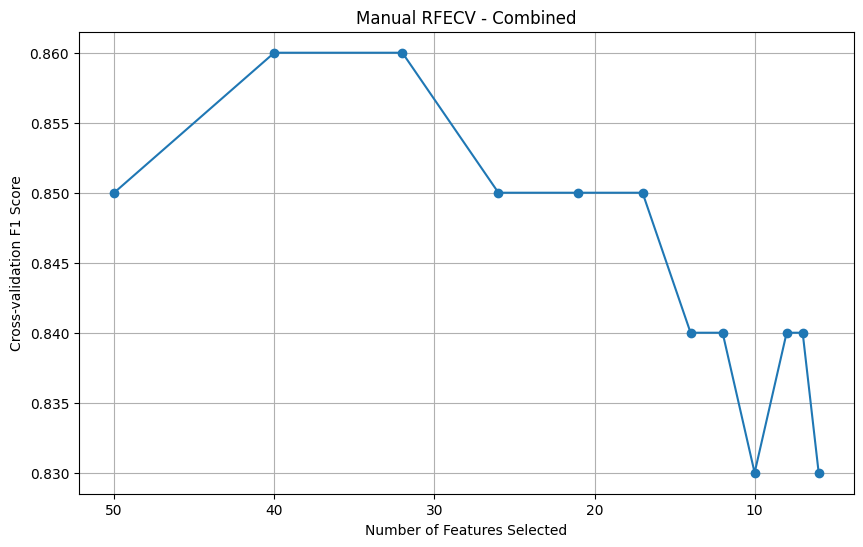


Skipping SMOTE. Using original training data.

Final datasets for 'Combined' stored with selected features.

Starting feature selection for 'Clinical' Dataset

Handling missing data with SimpleImputer...

Scaling features...

Performing L1-based feature selection...
Number of features after L1-based selection: 16

Skipping Mann-Whitney U Test for 'Clinical' dataset. Using L1-selected features.

Performing Stability Analysis with RFECV and Secondary Sorting based on Mean Feature Importance...
Number of stable features selected: 5

Stable Features Selected: ['PR_"{0_=_neg,\n1_=_pos}"_1', 'Tumor_Grade(M)\n(Mitotic)_3', 'ER_"{0_=_neg,\n1_=_pos}"_1', 'Race_and_Ethnicity_"{0_=_N/A\n1_=_white,\n2_=_black,\n3_=_asian,\n4_=_native,\n5_=_hispanic,\n6_=_multi,\n7_=_hawa,____8_=_amer_indian}"_2', 'Contralateral_Breast_Involvement_{0_=_no,_1_=_yes}_1']

Performing further feature selection using manual RFECV on stable features...

Best Features Selected after manual RFECV: ['PR_"{0_=_neg,\n1_=_pos

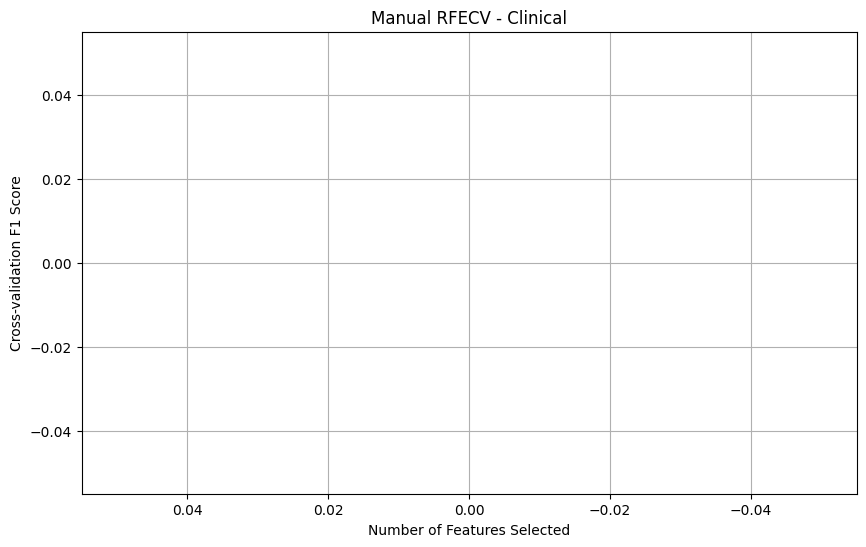


Skipping SMOTE. Using original training data.

Final datasets for 'Clinical' stored with selected features.

Starting feature selection for 'Image' Dataset

Handling missing data with SimpleImputer...

Scaling features...

Performing L1-based feature selection...
Number of features after L1-based selection: 100

Performing Mann-Whitney U Test feature selection with Bonferroni correction and parallelization...
Number of features after Mann-Whitney U Test: 71

Performing Stability Analysis with RFECV and Secondary Sorting based on Mean Feature Importance...
Number of stable features selected: 47

Stable Features Selected: ['feature_276', 'feature_382', 'feature_480', 'feature_2324', 'feature_3348', 'feature_3552', 'feature_6526', 'feature_10951', 'feature_11752', 'feature_16846', 'feature_19264', 'feature_20982', 'feature_21703', 'feature_21780', 'feature_21846', 'feature_21936', 'feature_21984', 'feature_22848', 'feature_22866', 'feature_23634', 'feature_23825', 'feature_24627', 'featu

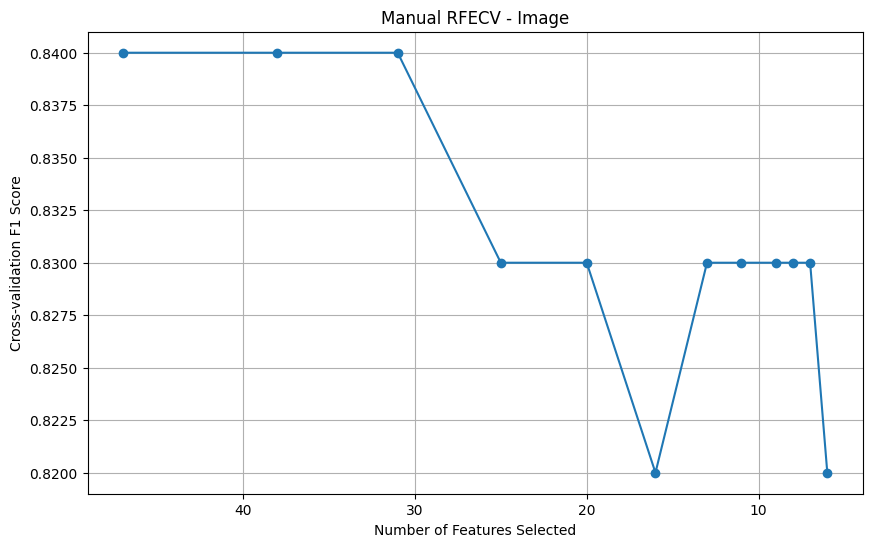


Skipping SMOTE. Using original training data.

Final datasets for 'Image' stored with selected features.


In [122]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import mannwhitneyu
from joblib import Parallel, delayed
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score 
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from sklearn.utils import resample
import logging
from sklearn.inspection import permutation_importance  # Added for permutation importance

# =================== Configurable Parameters ===================
MIN_FEATURES = 5          # Minimum number of features to select
MAX_FEATURES = None       # Maximum number of features to select (set to None to disable)
STABILITY_ITERATIONS = 10    # Number of iterations for stability analysis
STABILITY_THRESHOLD = 0.8    # Threshold for feature selection frequency (e.g., 0.8 for 80%)
# ===============================================================

# =================== Logging Configuration =====================
logging.basicConfig(
    filename='feature_selection_stability.log',
    filemode='a',
    format='%(asctime)s - %(levelname)s - %(message)s',
    level=logging.INFO
)
logger = logging.getLogger(__name__)
# ===============================================================

# =================== Custom Mann-Whitney U Test Feature Selector ===================
class MannWhitneyUTestFeatureSelector(BaseEstimator, TransformerMixin):
    """
    Custom transformer for feature selection using the Mann-Whitney U test
    with Bonferroni correction and optional parallelization.
    """
    def __init__(self, alpha=0.05, bonferroni=True, n_jobs=-1):
        self.alpha = alpha
        self.bonferroni = bonferroni
        self.n_jobs = n_jobs
        self.selected_features_ = None

    def _perform_test(self, col, X, y):
        group0 = X.loc[y == 0, col]
        group1 = X.loc[y == 1, col]
        try:
            _, p = mannwhitneyu(group0, group1, alternative='two-sided')
        except ValueError:
            p = 1  # Assign high p-value if test fails
        return p

    def fit(self, X, y):
        X = pd.DataFrame(X)
        y = pd.Series(y, index=X.index)
        p_values = Parallel(n_jobs=self.n_jobs)(
            delayed(self._perform_test)(col, X, y) for col in X.columns
        )
        self.p_values_ = np.array(p_values)
        if self.bonferroni:
            corrected_alpha = self.alpha / X.shape[1]
        else:
            corrected_alpha = self.alpha
        self.selected_features_ = X.columns[self.p_values_ < corrected_alpha]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.loc[:, self.selected_features_]
# =======================================================================================

# =================== Stability Analysis Function ===================
def perform_single_stability_iteration(i, X, y, groups, estimator, cv, scoring, min_features_to_select, step):
    logger.info(f"Stability Iteration {i+1}")

    # Group-wise Bootstrapping
    unique_groups = groups.unique()
    resampled_groups = resample(unique_groups, replace=True, random_state=42+i)
    mask = groups.isin(resampled_groups)
    X_sample = X.loc[mask].reset_index(drop=True)
    y_sample = y.loc[mask].reset_index(drop=True)
    groups_sample = groups.loc[mask].reset_index(drop=True)

    # RFECV Execution with Group-Aware Cross-Validation
    rfecv = RFECV(
        estimator=estimator,
        step=step,
        cv=cv,
        scoring=scoring,
        min_features_to_select=min_features_to_select,
        n_jobs=1  # Set to 1 to prevent over-parallelization
    )

    rfecv.fit(X_sample, y_sample, groups=groups_sample)
    selected = X_sample.columns[rfecv.support_].tolist()
    logger.info(f"Iteration {i+1}: Selected {len(selected)} features.")

    # Accumulate feature importances if available
    feature_importances = {}
    if hasattr(rfecv.estimator_, 'feature_importances_'):
        importances = rfecv.estimator_.feature_importances_
        for feature, importance in zip(X_sample.columns[rfecv.support_], importances):
            feature_importances[feature] = importance

    return selected, feature_importances

def perform_stability_analysis(X, y, groups, estimator, cv, scoring='f1',
                               min_features_to_select=5, step=1,
                               stability_iterations=10, stability_threshold=0.8,
                               max_features=None):
    feature_counts = Counter()
    feature_importances_total = defaultdict(float)  # To accumulate feature importances

    # Ensure groups is a pandas Series
    if not isinstance(groups, pd.Series):
        groups = pd.Series(groups).reset_index(drop=True)
    else:
        groups = groups.reset_index(drop=True)

    # Parallelize stability iterations
    results = Parallel(n_jobs=-1, verbose=0)(
        delayed(perform_single_stability_iteration)(
            i, X, y, groups, estimator, cv, scoring, min_features_to_select, step
        )
        for i in range(stability_iterations)
    )

    # Process results
    for selected, feature_importances in results:
        feature_counts.update(selected)
        for feature, importance in feature_importances.items():
            feature_importances_total[feature] += importance

    # Determine stable features based on threshold
    stable_features = [feature for feature, count in feature_counts.items()
                       if (count / stability_iterations) >= stability_threshold]

    # If the number of stable features exceeds max_features, sort by count and then by mean importance
    if max_features is not None and len(stable_features) > max_features:
        # Create a DataFrame for easier manipulation
        freq_df = pd.DataFrame.from_dict(feature_counts, orient='index', columns=['count'])
        freq_df['frequency'] = freq_df['count'] / stability_iterations
        # Filter based on stability threshold
        freq_df = freq_df[freq_df['frequency'] >= stability_threshold]

        # Calculate mean importance
        freq_df['mean_importance'] = freq_df.index.map(lambda x: feature_importances_total[x] / feature_counts[x])

        # Sort by count descending and then by mean importance descending
        freq_df_sorted = freq_df.sort_values(by=['count', 'mean_importance'], ascending=[False, False])

        # Select top max_features
        stable_features = freq_df_sorted.head(max_features).index.tolist()

    # Ensure at least min_features are selected
    if len(stable_features) < min_features_to_select:
        # Select top features to meet the minimum requirement
        stable_features = [feature for feature, count in feature_counts.most_common(min_features_to_select)]

    logger.info(f"Number of stable features selected: {len(stable_features)}")
    print(f"Number of stable features selected: {len(stable_features)}")

    return stable_features, feature_counts
# =======================================================================================

# =================== Modified Manual RFECV Function ===================
def manual_rfecv(X, y, groups, estimator, cv, scoring='f1', min_features_to_select=5, step=0.1, early_stopping_rounds=3):
    """
    Manually performs Recursive Feature Elimination with Cross-Validation (RFECV)
    using the specified estimator and cross-validation strategy.

    Parameters:
    - X (pd.DataFrame): Feature matrix.
    - y (pd.Series): Target vector.
    - groups (pd.Series or array-like): Group labels for the samples used while splitting the dataset.
    - estimator: The machine learning estimator to use for feature selection.
    - cv: Cross-validation strategy.
    - scoring (str): Scoring metric (default is 'f1').
    - min_features_to_select (int): Minimum number of features to select.
    - step (float): Proportion of features to remove at each iteration.
    - early_stopping_rounds (int): Number of rounds to wait for improvement before stopping.

    Returns:
    - best_features (list): The list of best selected features based on cross-validation score.
    - history (pd.DataFrame): History of number of features and corresponding CV scores.
    """

    n_features = X.shape[1]
    step_num = int(max(1, step * n_features))  # Convert the step percentage to an absolute number of features

    # History to keep track of scores, feature sets and feature counts
    history = []
    feature_sets = []

    # Copy X to avoid modifying the original dataframe
    X_remaining = X.copy()

    # Early stopping tracking
    no_improvement_rounds = 0
    best_score = -np.inf
    best_features = X_remaining.columns.tolist()

    while X_remaining.shape[1] > min_features_to_select:
        print(f"Evaluating with {X_remaining.shape[1]} features...")
        n_features_remaining = X_remaining.shape[1]
        step_num = int(max(1, step * n_features_remaining)) 

        # Custom cross-validation loop
        scores = []
        for train_idx, test_idx in cv.split(X_remaining, y, groups):
            X_train_cv, X_valid_cv = X_remaining.iloc[train_idx], X_remaining.iloc[test_idx]
            y_train_cv, y_valid_cv = y.iloc[train_idx], y.iloc[test_idx]
            estimator.fit(X_train_cv, y_train_cv)
            y_pred_cv = estimator.predict(X_valid_cv)
            score = f1_score(y_valid_cv, y_pred_cv)
            scores.append(score)
        avg_score = np.mean(scores)
        avg_score = round(avg_score, 2)  # Round CV score to 3 decimal places

        # Append results to the history and store the current feature set
        history.append((X_remaining.shape[1], avg_score))
        feature_sets.append(X_remaining.columns.tolist())

        # Early stopping check (Modified)
        if avg_score > best_score:
            best_score = avg_score
            best_features = X_remaining.columns.tolist()
            no_improvement_rounds = 0
        elif avg_score == best_score:
            # Prefer the smaller feature set
            if len(X_remaining.columns) < len(best_features):
                best_features = X_remaining.columns.tolist()
            no_improvement_rounds = 0  # Reset since performance hasn't degraded
        else:
            no_improvement_rounds += 1

        if no_improvement_rounds >= early_stopping_rounds:
            print("Early stopping, no significant improvement.")
            break

        # Train the model and get feature importances using permutation importance
        estimator.fit(X_remaining, y)
        # Compute permutation importances
        perm_importance = permutation_importance(
            estimator, X_remaining, y, n_repeats=10, random_state=42, scoring=scoring, n_jobs=-1
        )
        importances = perm_importance.importances_mean

        # Create a DataFrame of features and importances
        feature_importances = pd.DataFrame({
            'feature': X_remaining.columns,
            'importance': importances
        })

        # Sort features by importance (ascending)
        feature_importances.sort_values(by='importance', ascending=True, inplace=True)

        # Remove the least important features based on step size
        n_to_remove = min(step_num, X_remaining.shape[1] - min_features_to_select)
        if n_to_remove <= 0:
            # Cannot remove more features without going below min_features_to_select
            break

        features_to_remove = feature_importances.head(n_to_remove)['feature'].tolist()

        # Drop the least important features
        X_remaining.drop(columns=features_to_remove, inplace=True)

    # Convert history to a DataFrame for easy access
    history_df = pd.DataFrame(history, columns=['n_features', 'cv_score'])

    return best_features, history_df

# =======================================================================================

# =================== Feature Selection Pipeline ===================
# Assuming data_splits is a dictionary with keys as dataset names and values as dictionaries:
# {
#     'Dataset1': {
#         'X_train_full': ...,
#         'X_test_full': ...,
#         'y_train_full': ...,
#         'y_test': ...,
#         'patient_ids_train': ...,
#         'patient_ids_test': ...
#     },
#     'Dataset2': { ... },
#     ...
# }

selected_features_dict = {}

apply_smote = False        # Set to False if you want to skip SMOTE
apply_mannwhitney = True   # Set to False if you want to skip Mann-Whitney U Test

datasets_to_skip_mannwhitney = ['Clinical', 'RadiomicsOnly', 'ClinicalRadiomics']
datasets_to_skip_L1 = ['Clinical', 'RadiomicsOnly', 'ClinicalRadiomics']
datasets_for_standard = ['RadiomicsOnly', 'ClinicalRadiomics']

for dataset_name in data_splits.keys():

    logger.info(f"\nStarting feature selection for '{dataset_name}' Dataset")
    print(f"\nStarting feature selection for '{dataset_name}' Dataset")

    # Retrieve data
    data = data_splits[dataset_name]
    X_train_full = data['X_train_full']
    y_train_full = data['y_train_full']
    X_test_full = data['X_test_full']
    y_test = data['y_test']
    patient_ids_train = data['patient_ids_train']  # Preserving group labels
    patient_ids_test = data['patient_ids_test']

    # Handle Missing Data - Imputation
    logger.info("\nHandling missing data with SimpleImputer...")
    print("\nHandling missing data with SimpleImputer...")
    imputer = SimpleImputer(strategy='mean')
    X_train_imputed = imputer.fit_transform(X_train_full)
    X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train_full.columns, index=X_train_full.index)

    # Feature Scaling using MinMaxScaler or StandardScaler
    logger.info("\nScaling features...")
    print("\nScaling features...")
    if dataset_name in datasets_for_standard:
        scaler = StandardScaler()
    else:
        scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_full.columns, index=X_train_full.index)

    # L1-based Feature Selection
    logger.info("\nPerforming L1-based feature selection...")
    print("\nPerforming L1-based feature selection...")
    if dataset_name in datasets_to_skip_L1:
        l1_selector = SelectFromModel(
            LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000)
        )
    else:
        l1_selector = SelectFromModel(
            LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000),
            max_features=100  # Adjust as needed or set to None
        )
    l1_selector.fit(X_train_scaled, y_train_full)
    X_train_l1 = l1_selector.transform(X_train_scaled)
    selected_L1_features = X_train_scaled.columns[l1_selector.get_support()].tolist()
    X_train_l1 = pd.DataFrame(X_train_l1, columns=selected_L1_features)
    logger.info(f"Number of features after L1-based selection: {X_train_l1.shape[1]}")
    print(f"Number of features after L1-based selection: {X_train_l1.shape[1]}")

    # Mann-Whitney U Test Feature Selection
    if apply_mannwhitney and dataset_name not in datasets_to_skip_mannwhitney:
        logger.info("\nPerforming Mann-Whitney U Test feature selection with Bonferroni correction and parallelization...")
        print("\nPerforming Mann-Whitney U Test feature selection with Bonferroni correction and parallelization...")
        mannwhitney_selector = MannWhitneyUTestFeatureSelector(alpha=0.05, bonferroni=True, n_jobs=-1)
        mannwhitney_selector.fit(X_train_l1, y_train_full)
        X_train_mwu = mannwhitney_selector.transform(X_train_l1)
        logger.info(f"Number of features after Mann-Whitney U Test: {X_train_mwu.shape[1]}")
        print(f"Number of features after Mann-Whitney U Test: {X_train_mwu.shape[1]}")
    else:
        logger.info(f"\nSkipping Mann-Whitney U Test for '{dataset_name}' dataset. Using L1-selected features.")
        print(f"\nSkipping Mann-Whitney U Test for '{dataset_name}' dataset. Using L1-selected features.")
        X_train_mwu = X_train_l1

    # Stability Analysis with RFECV and Secondary Sorting
    logger.info("\nPerforming Stability Analysis with RFECV and Secondary Sorting based on Mean Feature Importance...")
    print("\nPerforming Stability Analysis with RFECV and Secondary Sorting based on Mean Feature Importance...")

    rf_estimator = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=100, max_depth=5)
    cv_strategy = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

    stable_features, feature_counts = perform_stability_analysis(
        X_train_mwu,
        y_train_full,
        groups=patient_ids_train,
        estimator=rf_estimator,
        cv=cv_strategy,
        scoring='f1',
        min_features_to_select=MIN_FEATURES,
        step=1,                # Remove one feature at a time
        stability_iterations=STABILITY_ITERATIONS,
        stability_threshold=STABILITY_THRESHOLD,
        max_features=MAX_FEATURES  # Set to None to remove the upper limit
    )

    logger.info(f"\nStable Features Selected: {stable_features}")
    print(f"\nStable Features Selected: {stable_features}")

    # If MAX_FEATURES is None, perform manual RFECV on stable features
    if MAX_FEATURES is None:
        logger.info("\nPerforming further feature selection using manual RFECV on stable features...")
        print("\nPerforming further feature selection using manual RFECV on stable features...")

        manual_rfecv_estimator = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=100, max_depth=5)
        manual_rfecv_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

        best_features, rfecv_history = manual_rfecv(
            X_train_mwu[stable_features],
            y_train_full,
            groups=patient_ids_train,
            estimator=manual_rfecv_estimator,
            cv=manual_rfecv_cv,
            scoring='f1',
            min_features_to_select=MIN_FEATURES,
            step=0.2,  # For example, remove 5% of features each iteration
            early_stopping_rounds=10
        )

        logger.info(f"\nBest Features Selected after manual RFECV: {best_features}")
        print(f"\nBest Features Selected after manual RFECV: {best_features}")

        # Optionally, plot the history
        plt.figure(figsize=(10, 6))
        plt.plot(rfecv_history['n_features'], rfecv_history['cv_score'], marker='o')
        plt.xlabel("Number of Features Selected")
        plt.ylabel("Cross-validation F1 Score")
        plt.title(f"Manual RFECV - {dataset_name}")
        plt.gca().invert_xaxis()  # Optional: Invert x-axis to show decreasing number of features
        plt.grid(True)
        plt.show()

        # Set final selected features to best_features
        final_selected_features = best_features
    else:
        final_selected_features = stable_features

    # Apply SMOTE **after** feature selection
    if apply_smote:
        logger.info("\nApplying SMOTE to balance the classes after feature selection...")
        print("\nApplying SMOTE to balance the classes after feature selection...")
        smote = SMOTE(random_state=42, n_jobs=-1)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_mwu[final_selected_features], y_train_full)
        X_train_resampled = pd.DataFrame(X_train_resampled, columns=final_selected_features).reset_index(drop=True)
        y_train_resampled = pd.Series(y_train_resampled).reset_index(drop=True)
        logger.info(f"Number of samples after SMOTE: {X_train_resampled.shape[0]}")
        print(f"Number of samples after SMOTE: {X_train_resampled.shape[0]}")
        logger.info(f"Class distribution after SMOTE:\n{y_train_resampled.value_counts()}")
        print(f"Class distribution after SMOTE:\n{y_train_resampled.value_counts()}")
    else:
        logger.info("\nSkipping SMOTE. Using original training data.")
        print("\nSkipping SMOTE. Using original training data.")
        X_train_resampled = X_train_mwu[final_selected_features].reset_index(drop=True)
        y_train_resampled = y_train_full.reset_index(drop=True)

    # Ensure that all selected features exist in the test dataset
    missing_in_train = set(final_selected_features) - set(X_train_full.columns)
    missing_in_test = set(final_selected_features) - set(X_test_full.columns)
    if missing_in_train:
        raise ValueError(f"The following selected features are missing in X_train_full: {missing_in_train}")
    if missing_in_test:
        raise ValueError(f"The following selected features are missing in X_test_full: {missing_in_test}")

    # Subset the original X_train_full and X_test_full to include only the selected features
    X_test_final = X_test_full[final_selected_features].copy().reset_index(drop=True)
    y_test_final = y_test.reset_index(drop=True)

    # Store the final datasets with selected features in data_splits
    data_splits[dataset_name] = {
        'X_train_full': X_train_resampled,
        'X_test_full': X_test_final,
        'y_train_full': y_train_resampled,
        'y_test': y_test_final,
        'patient_ids_train': patient_ids_train.reset_index(drop=True),
        'patient_ids_test': patient_ids_test.reset_index(drop=True)
    }

    selected_features_dict[dataset_name] = final_selected_features
    logger.info(f"\nFinal datasets for '{dataset_name}' stored with selected features.")
    print(f"\nFinal datasets for '{dataset_name}' stored with selected features.")
# =======================================================================================


In [137]:
# Create a new dataset 'CombinedSelected' that combines the selected features from 'Clinical' and 'Image' datasets

print("\nCreating new dataset 'CombinedSelected' from the selected features of 'Clinical' and 'Image' datasets.")

# Retrieve the selected features for 'Clinical' and 'Image' datasets
clinical_selected_features = selected_features_dict['Clinical']
image_selected_features = selected_features_dict['Image']

# Identify overlapping features and remove them from the Image selection
overlapping_features = set(clinical_selected_features).intersection(set(image_selected_features))
if overlapping_features:
    print(f"Overlapping features detected: {overlapping_features}")
    logger.info(f"Overlapping features detected: {overlapping_features}")
    image_selected_features = [feat for feat in image_selected_features if feat not in overlapping_features]
    print(f"Adjusted Image selected features to remove overlaps: {image_selected_features}")
    logger.info(f"Adjusted Image selected features to remove overlaps: {image_selected_features}")

# Retrieve full datasets before splitting from data_variations
# For Clinical, data_variations['Clinical'] is assumed to be a 3-tuple: (X_clinical_full, y_clinical_full, groups_clinical)
# For Image, check if a meta DataFrame (with aug_id) is provided (4-tuple)
X_clinical_full, y_clinical_full, groups_clinical = data_variations['Clinical']
if len(data_variations['Image']) == 4:
    X_image_full, y_image_full, groups_image, meta_image = data_variations['Image']
else:
    X_image_full, y_image_full, groups_image = data_variations['Image']
    meta_image = None



################################################################################################
### for test full distribution data
# Retrieve full datasets before splitting from data_variations
# For Clinical, data_variations['Clinical'] is assumed to be a 3-tuple: (X_clinical_full, y_clinical_full, groups_clinical)
# For Image, check if a meta DataFrame (with aug_id) is provided (4-tuple)
X_clinical_full_test, y_clinical_full_test, groups_clinical_test = data_variations_test['Clinical']
if len(data_variations_test['Image']) == 4:
    X_image_full_test, y_image_full_test, groups_image_test, meta_image_test = data_variations_test['Image']
else:
    X_image_full_test, y_image_full_test, groups_image_test = data_variations_test['Image']
    meta_image_test = None
################################################################################################  

# Apply the selected features to the full datasets
X_clinical_selected = X_clinical_full[clinical_selected_features].copy()
X_image_selected = X_image_full[image_selected_features].copy()

################################################################################################
### for test full distribution data
# Apply the selected features to the full datasets
X_clinical_selected_test = X_clinical_full_test[clinical_selected_features].copy()
X_image_selected_test = X_image_full_test[image_selected_features].copy()
################################################################################################


# Add 'patient_id' to each dataset
X_clinical_selected['patient_id'] = groups_clinical.astype(str)
X_image_selected['patient_id'] = groups_image.astype(str)
# If meta info exists for the Image dataset, add the aug_id column to the selected features
if meta_image is not None and 'aug_id' in meta_image.columns:
    X_image_selected['aug_id'] = meta_image['aug_id'].values

# Merge the clinical and image datasets on 'patient_id'
combined_df = pd.merge(X_clinical_selected, X_image_selected, on='patient_id', how='inner')
combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()]  # Remove duplicates if any
assert not combined_df.columns.duplicated().any(), "Duplicate columns still exist in combined_df."

# Load clinical data to retrieve the response variable
clinical_data_processed = load_clinical_data(clinical_data_path)
y_combined = combined_df.merge(
    clinical_data_processed[['patient_id', 'response']],
    on='patient_id',
    how='left'
)['response'].astype(int)

# Extract patient IDs (groups)
groups_combined = combined_df['patient_id']
# Keep the combined features including the aug_id column (if present)
X_combined = combined_df.copy()  # Optionally, you could drop patient_id later if desired


################################################################################################
# Add 'patient_id' to each dataset
X_clinical_selected_test['patient_id'] = groups_clinical_test.astype(str)
X_image_selected_test['patient_id'] = groups_image_test.astype(str)
# If meta info exists for the Image dataset, add the aug_id column to the selected features
if meta_image_test is not None and 'aug_id' in meta_image_test.columns:
    X_image_selected_test['aug_id'] = meta_image_test['aug_id'].values

# Merge the clinical and image datasets on 'patient_id'
combined_df_test = pd.merge(X_clinical_selected_test, X_image_selected_test, on='patient_id', how='inner')
combined_df_test = combined_df_test.loc[:, ~combined_df_test.columns.duplicated()]  # Remove duplicates if any
assert not combined_df_test.columns.duplicated().any(), "Duplicate columns still exist in combined_df_test."

y_combined_test = combined_df_test.merge(
    clinical_data_processed[['patient_id', 'response']],
    on='patient_id',
    how='left'
)['response'].astype(int)

# Extract patient IDs (groups)
groups_combined_test = combined_df_test['patient_id']
# Keep the combined features including the aug_id column (if present)
X_combined_test = combined_df_test.copy()  # Optionally, you could drop patient_id later if desired
################################################################################################


# Perform train-test split for the 'CombinedSelected' dataset using stratified group splitting
train_idx, test_idx = stratified_group_split(X_combined, y_combined, groups_combined, test_size=0.3, random_state=42)

X_train_full = X_combined.loc[train_idx].reset_index(drop=True)
y_train_full = y_combined.loc[train_idx].reset_index(drop=True)
X_test_full = X_combined.loc[test_idx].reset_index(drop=True)
y_test = y_combined.loc[test_idx].reset_index(drop=True)

# # If the combined features include an 'aug_id' column, filter the test set to keep only originals (aug_id == "0")
# if 'aug_id' in X_test_full.columns:
#     original_mask = X_test_full['aug_id'] == '0'
#     X_test_full = X_test_full.loc[original_mask].reset_index(drop=True)
#     y_test = y_test.loc[original_mask].reset_index(drop=True)




patient_ids_train = groups_combined.loc[train_idx].reset_index(drop=True)
patient_ids_test = groups_combined.loc[test_idx].reset_index(drop=True)

groups_combined_test_series = pd.Series(groups_combined_test).reset_index(drop=True)
mask = groups_combined_test_series.isin(patient_ids_test)
X_test_full = X_combined_test.loc[mask].reset_index(drop=True)
y_test = pd.Series(y_combined_test).reset_index(drop=True).loc[mask].reset_index(drop=True)

X_train_full = X_train_full.drop(columns=['patient_id', 'aug_id'], errors='ignore')
X_test_full = X_test_full.drop(columns=['patient_id', 'aug_id'], errors='ignore')



# Store the final splits in data_splits
data_splits['CombinedSelected'] = {
    'X_train_full': X_train_full,
    'X_test_full': X_test_full,
    'y_train_full': y_train_full,
    'y_test': y_test,
    'patient_ids_train': patient_ids_train,
    'patient_ids_test': patient_ids_test
}

print("New dataset 'CombinedSelected' created and added to data_splits.")
logger.info("New dataset 'CombinedSelected' created and added to data_splits.")



Creating new dataset 'CombinedSelected' from the selected features of 'Clinical' and 'Image' datasets.
Loading clinical data...
Clinical data loaded and processed.
New dataset 'CombinedSelected' created and added to data_splits.


In [124]:
print("Training set class distribution:")
print(data_splits['CombinedSelected']['y_train_full'].value_counts(normalize=True))
print("Test set class distribution:")
print(data_splits['CombinedSelected']['y_test'].value_counts(normalize=True))

Training set class distribution:
response
1    0.54345
0    0.45655
Name: proportion, dtype: float64
Test set class distribution:
response
0    0.773585
1    0.226415
Name: proportion, dtype: float64


In [140]:
#=================== Define Classifiers and Parameter Grids ===================
# Define classifiers with balanced class weights to handle class imbalance
classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=200,  # Increased iterations for better convergence
        solver='liblinear',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    'LightGBM': lgb.LGBMClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'SVM': SVC(
        probability=True,
        random_state=42,
        max_iter=5000,
        class_weight='balanced'
    )
}

# Define parameter grids with extensive ranges for robust hyperparameter tuning
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10],
        'classifier__penalty': ['l1', 'l2']
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [None, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__max_features': ['sqrt', 'log2', None]
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 150, 200],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__max_depth': [3, 5, 7],
        'classifier__subsample': [0.6, 0.8, 1.0]
    },
    'XGBoost': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__max_depth': [3, 5, 7],
        'classifier__subsample': [0.6, 0.8, 1.0],
        'classifier__colsample_bytree': [0.6, 0.8, 1.0],
        'classifier__min_child_weight': [1, 3, 5],
        'classifier__reg_alpha': [0, 0.01, 0.1],
        'classifier__reg_lambda': [1, 1.5, 2]
    },
    'LightGBM': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__num_leaves': [20, 31, 40],
        'classifier__min_child_samples': [20, 30, 50],
        'classifier__subsample': [0.6, 0.8, 1.0],
        'classifier__colsample_bytree': [0.6, 0.8, 1.0],
        'classifier__max_depth': [-1, 10, 20]
    },
    'SVM': {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']
    }
}

In [141]:
# =================== Define Classifiers and Parameter Grids ===================


## Define classifiers with balanced class weights to handle class imbalance
#classifiers = {
#    'Logistic Regression': LogisticRegression(
#        max_iter=100,
#        solver='liblinear',
#        random_state=42
#    ),
#    'Random Forest': RandomForestClassifier(
#        class_weight='balanced',
#        random_state=42,
#        n_jobs=-1
#    ),
#    #'Gradient Boosting': GradientBoostingClassifier(
#    #    random_state=42
#    #),
#    'XGBoost': xgb.XGBClassifier(
#        eval_metric='logloss',
#        random_state=42,
#        n_jobs=-1 # Suppress warning in newer versions
#    ),
#    'LightGBM': lgb.LGBMClassifier(
#        class_weight='balanced',
#        random_state=42,
#        n_jobs=-1
#    ),
#    #'SVM': SVC(
#    #    kernel='rbf',
#    #    probability=True,
#    #    random_state=42,
#    #    max_iter=5000,
#    #    class_weight='balanced'
#    #)
#}
#
## Define parameter grids with adjustments to prevent overfitting
#param_grids = {
#    'XGBoost': {
#        'classifier__n_estimators': [50,100],  # Reduced range
#        'classifier__learning_rate': [0.05, 0.1],  # Added 0.05 for finer tuning
#        'classifier__max_depth': [3,5],  # Limited to prevent overly complex trees
#        'classifier__subsample': [0.4, 0.6],  # Control overfitting by subsampling
#        'classifier__colsample_bytree': [0.4, 0.6]  # Control overfitting by feature subsampling
#    },
#    'LightGBM': {
#        'classifier__n_estimators': [50,100],  # Reduced range
#        'classifier__learning_rate': [0.05, 0.1],  # Added 0.05 for finer tuning
#        'classifier__num_leaves': [20],  # Limited to control model complexity
#        'classifier__min_child_samples': [20, 50],  # Prevent overfitting by setting minimum samples
#        'classifier__subsample': [0.4,0.6],  # Control overfitting by subsampling
#        'classifier__colsample_bytree': [0.4, 0.6],  # Control overfitting by feature subsampling
#        'classifier__verbose': [-1]
#    },
#    'Random Forest': {
#        'classifier__n_estimators': [50, 100],  # Focused on higher n_estimators for stability
#        'classifier__max_depth': [10, 15],  # Limited depth to prevent overfitting
#        'classifier__min_samples_split': [5, 10],  # Increased to ensure splits are meaningful
#        'classifier__min_samples_leaf': [2, 4],  # Increased to prevent leaves from being too specific
#        'classifier__max_features': ['sqrt', 'log2']  # Control over feature selection per split
#    },
#    'Gradient Boosting': {
#        'classifier__n_estimators': [80, 100],  # Focused on higher n_estimators for stability
#        'classifier__learning_rate': [0.05, 0.1],  # Added 0.05 for finer tuning
#        'classifier__max_depth': [3, 5]  # Limited depth to prevent overfitting
#    #    'classifier__subsample': [0.4, 0.6],  # Control overfitting by subsampling
#    #    'classifier__min_samples_split': [5, 10],  # Increased to ensure splits are meaningful
#    #    'classifier__min_samples_leaf': [2, 4]  # Increased to prevent leaves from being too specific
#    },
#    'Logistic Regression': {
#        'classifier__C': [0.01],  # Smaller range to enforce regularization
#        'classifier__penalty': ['l1']  # Keep both penalties for flexibility
#    },
#    'SVM': {
#        'classifier__C': [0.1, 1],  # Removed C=10 to prevent overfitting
#        'classifier__kernel': ['linear', 'rbf'],
#        'classifier__gamma': ['scale', 'auto']  # Added gamma for 'rbf' kernel
#    }
#}
# ===================================================================================


In [142]:
# Function: Nested Cross Validation for Hyperparameter Tuning

def nested_cv_evaluation(dataset_name, X, y, groups, classifiers, param_grids, outer_splits=3, inner_splits=2):
    """
    Performs nested cross-validation with hyperparameter tuning and group-aware splitting.
    """
    print(f"\nStarting Nested CV for {dataset_name} dataset...")
    outer_cv = StratifiedGroupKFold(n_splits=outer_splits, shuffle=True, random_state=42)
    aggregated_scores = {}
    best_estimators = {}
    nested_scores = {name: [] for name in classifiers.keys()}
    cv_results_all = {name: [] for name in classifiers.keys()}  # To store cv_results_

    for name, base_classifier in classifiers.items():
        print(f"\nEvaluating {name} on {dataset_name} dataset...")
        start_time = time.time()
        scores = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
        best_estimators[name] = []
        cv_results_list = []  # To collect cv_results_ from each outer fold

        for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups=groups), 1):
            print(f"  Outer Fold {fold}/{outer_splits}")
            X_train_fold, X_valid = X.iloc[train_idx], X.iloc[test_idx]
            y_train_fold, y_valid = y.iloc[train_idx], y.iloc[test_idx]
            groups_train_fold = groups.iloc[train_idx]

            # Define the inner cross-validation with group awareness
            inner_cv = StratifiedGroupKFold(n_splits=inner_splits, shuffle=True, random_state=42)


            # **Compute scale_pos_weight for XGBoost and LightGBM**
            if name == 'XGBoost' or name == 'LightGBM':
                scale_pos_weight = (y_train_fold == 0).sum() / (y_train_fold == 1).sum()
                print(f"Computed scale_pos_weight: {scale_pos_weight:.4f} for {name}")
                # Clone the base classifier to avoid modifying the original
                classifier = clone(base_classifier)
                classifier.set_params(scale_pos_weight=scale_pos_weight)
            else:
                classifier = clone(base_classifier)

            # Define the pipeline
            pipeline = ImbPipeline(steps=[
                ('scaler', MinMaxScaler()),
                ('classifier', classifier)
            ])

            # Hyperparameter tuning with RandomizedSearchCV
            search = RandomizedSearchCV(
                estimator=pipeline,
                param_distributions=param_grids[name],
                scoring='f1',
                n_iter=5,  # Adjusted for efficiency
                cv=inner_cv.split(X_train_fold, y_train_fold, groups=groups_train_fold),
                random_state=42,
                n_jobs=-1
            )

            # Fit the model on the training fold
            search.fit(X_train_fold, y_train_fold)

            # Get the best estimator
            best_model = search.best_estimator_

            # Evaluate on the validation fold
            y_pred = best_model.predict(X_valid)

            # Compute metrics
            accuracy = accuracy_score(y_valid, y_pred)
            precision = precision_score(y_valid, y_pred, zero_division=0)
            recall = recall_score(y_valid, y_pred)
            f1 = f1_score(y_valid, y_pred)

            # Append scores
            scores['accuracy'].append(accuracy)
            scores['precision'].append(precision)
            scores['recall'].append(recall)
            scores['f1'].append(f1)
            nested_scores[name].append(f1)

            # Store the best estimator
            best_estimators[name].append(best_model)

            # Collect cv_results_
            cv_results = pd.DataFrame(search.cv_results_)
            cv_results_list.append(cv_results)

        # Aggregate scores
        aggregated_scores[name] = {metric: (np.mean(scores[metric]), np.std(scores[metric])) for metric in scores}

        # Combine cv_results_ from all outer folds
        cv_results_all[name] = pd.concat(cv_results_list, ignore_index=True)

        elapsed_time = time.time() - start_time
        print(f"{name} - Completed in {elapsed_time:.2f} seconds")
        print(f"Aggregated Scores for {name}: {aggregated_scores[name]}")

    return aggregated_scores, best_estimators, nested_scores, cv_results_all


In [143]:
# Nested CV for Hyperparameter Tuning

nested_cv_results = {}  # To store nested CV results
for dataset_name in data_splits.keys():
    print(f"\nStarting Nested Cross-Validation for {dataset_name} Dataset")

    # Retrieve data
    data = data_splits[dataset_name]
    X_train_full = data['X_train_full']
    y_train_full = data['y_train_full']
    groups_train = data['patient_ids_train']

    # Perform nested cross-validation
    aggregated_scores, best_estimators, nested_scores, cv_results_all = nested_cv_evaluation(
        dataset_name, X_train_full, y_train_full, groups_train, classifiers, param_grids
    )

    # Store the results
    nested_cv_results[dataset_name] = {
        'aggregated_scores': aggregated_scores,
        'best_estimators': best_estimators,
        'nested_scores': nested_scores,
        'cv_results_all': cv_results_all
    }



Starting Nested Cross-Validation for Combined Dataset

Starting Nested CV for Combined dataset...

Evaluating Logistic Regression on Combined dataset...
  Outer Fold 1/3
  Outer Fold 2/3
  Outer Fold 3/3
Logistic Regression - Completed in 8.63 seconds
Aggregated Scores for Logistic Regression: {'accuracy': (np.float64(0.8751556637706592), np.float64(0.045411021955796)), 'precision': (np.float64(0.8954627846380424), np.float64(0.0738447552826821)), 'recall': (np.float64(0.8596063208420079), np.float64(0.043095888872429045)), 'f1': (np.float64(0.8764097736196391), np.float64(0.05430123098926441))}

Evaluating Random Forest on Combined dataset...
  Outer Fold 1/3
  Outer Fold 2/3
  Outer Fold 3/3
Random Forest - Completed in 6.85 seconds
Aggregated Scores for Random Forest: {'accuracy': (np.float64(0.8329729394720703), np.float64(0.038247051483767044)), 'precision': (np.float64(0.882804337179781), np.float64(0.10176441372124566)), 'recall': (np.float64(0.7981103978718482), np.float64(0.0

/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/env/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/env/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


  Outer Fold 2/3


/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/env/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/env/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


  Outer Fold 3/3


...

  Outer Fold 2/3


/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/env/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/env/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


  Outer Fold 3/3


/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/env/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/mohammad.enayet/Documents/Personal/Research/sparkMLproject/env/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVM - Completed in 2.14 seconds
Aggregated Scores for SVM: {'accuracy': (np.float64(0.8600135662898537), np.float64(0.0015398173769879914)), 'precision': (np.float64(0.9319189482428278), np.float64(0.015430928611211508)), 'recall': (np.float64(0.7989670042178805), np.float64(0.028953681029760578)), 'f1': (np.float64(0.8597951289928379), np.float64(0.011807888186387982))}


In [144]:
data_splits['CombinedSelected']['X_train_full']

,"PR_""{0_=_neg,\n1_=_pos}""_1",Tumor_Grade(M)\n(Mitotic)_3,"ER_""{0_=_neg,\n1_=_pos}""_1","Race_and_Ethnicity_""{0_=_N/A\n1_=_white,\n2_=_black,\n3_=_asian,\n4_=_native,\n5_=_hispanic,\n6_=_multi,\n7_=_hawa,____8_=_amer_indian}""_2","Contralateral_Breast_Involvement_{0_=_no,_1_=_yes}_1",feature_382,feature_480,feature_3552,feature_6526,feature_10951,...,feature_5099,feature_8062,feature_10801,feature_12208,feature_13741,feature_14315,feature_15119,feature_19300,feature_22930,feature_18071
0,0,0,0,1,0,0.000000,0.0,0.0,0.000000,0.297544,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.000000
1,0,0,0,1,0,0.000000,0.0,0.0,0.000000,0.278271,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.000000
2,0,0,0,1,0,0.000000,0.0,0.0,0.065613,0.045971,...,0.0,0.023348,0.000000,0.111060,0.0,0.000000,0.000000,0.000000,0.00000,0.000000
3,0,0,0,1,0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.000000
4,0,0,0,1,0,0.000000,0.0,0.0,0.076131,0.069551,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3079,1,1,1,0,0,0.000000,0.0,0.0,0.029760,0.020753,...,0.0,0.190992,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.157926
3080,1,1,1,0,0,0.169156,0.0,0.0,0.342064,0.023507,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.024557,0.178587,0.40443,0.154880
3081,1,1,1,0,0,0.000000,0.0,0.0,0.000000,0.033199,...,0.0,0.120129,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.000000
3082,1,1,1,0,0,0.085010,0.0,0.0,0.313633,0.016263,...,0.0,0.000000,0.198058,0.049856,0.0,0.000000,0.043241,0.269372,0.00000,0.000000


In [145]:
data_splits['CombinedSelected']['X_test_full']

,"PR_""{0_=_neg,\n1_=_pos}""_1",Tumor_Grade(M)\n(Mitotic)_3,"ER_""{0_=_neg,\n1_=_pos}""_1","Race_and_Ethnicity_""{0_=_N/A\n1_=_white,\n2_=_black,\n3_=_asian,\n4_=_native,\n5_=_hispanic,\n6_=_multi,\n7_=_hawa,____8_=_amer_indian}""_2","Contralateral_Breast_Involvement_{0_=_no,_1_=_yes}_1",feature_382,feature_480,feature_3552,feature_6526,feature_10951,...,feature_5099,feature_8062,feature_10801,feature_12208,feature_13741,feature_14315,feature_15119,feature_19300,feature_22930,feature_18071
0,0,1,0,0,0,0.254123,0.000000,0.000000,0.00000,0.100886,...,0.0,0.043095,0.000000,0.029197,0.0000,0.000000,0.000000,0.000000,0.0,0.000000
1,0,1,0,0,0,0.350763,0.000000,0.243502,0.00000,0.119078,...,0.0,0.000000,0.000000,0.000000,0.0147,0.000000,0.000000,0.000000,0.0,0.388711
2,0,1,0,0,0,0.290441,0.000000,0.369992,0.00000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.0,0.000000
3,0,1,0,0,0,0.474810,0.020987,0.202486,0.00000,0.047892,...,0.0,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.0,0.318671
4,0,1,0,0,0,0.620195,0.180384,0.270686,0.00000,0.025577,...,0.0,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4765,0,0,0,1,1,0.483129,0.007210,0.225004,0.00000,0.129894,...,0.0,0.000000,0.000000,0.015887,0.0000,0.000000,0.097403,0.305273,0.0,0.000000
4766,0,0,0,1,1,0.381252,0.286452,0.670027,0.09088,0.247389,...,0.0,0.069787,0.099451,0.000000,0.0000,0.000000,0.000000,0.376449,0.0,0.220190
4767,0,0,0,1,1,0.096895,0.200129,0.446531,0.00000,0.385011,...,0.0,0.000000,0.000000,0.000000,0.0000,0.000000,0.470663,0.624629,0.0,0.148518
4768,0,0,0,1,1,0.591438,0.119930,0.460076,0.00000,0.211430,...,0.0,0.000000,0.000000,0.105676,0.0000,0.031971,0.587474,0.805089,0.0,0.000000


In [146]:
# Retrain Models on Entire Training Set Using Best Hyperparameters and Evaluate on Test Set

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
from sklearn.base import clone

test_results = {}  # To store test set results

for dataset_name in data_splits.keys():
    print(f"\nRetraining and Evaluating Models for {dataset_name} Dataset")
    
    # Retrieve data splits for the current dataset
    data = data_splits[dataset_name]
    X_train_full = data['X_train_full']
    y_train_full = data['y_train_full']
    X_test_full = data['X_test_full']
    y_test = data['y_test']
    groups_train = data['patient_ids_train']
    groups_test = data['patient_ids_test']
    
    # Reset indices to ensure consistency
    X_train_full = X_train_full.reset_index(drop=True)
    y_train_full = y_train_full.reset_index(drop=True)
    X_test_full = X_test_full.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)
    
    # Get nested CV results for the current dataset
    nested_results = nested_cv_results[dataset_name]
    cv_results_all = nested_results['cv_results_all']
    
    test_results[dataset_name] = {}  # Initialize dictionary to store test results for each classifier
    
    for classifier_name in classifiers.keys():
        print(f"\nRetraining {classifier_name} on {dataset_name} dataset...")
        
        # Get cross-validation results for the current classifier
        cv_results = cv_results_all[classifier_name]
        
        # Find the hyperparameters with the best mean_test_score (which is F1 score)
        max_mean_test_score = cv_results['mean_test_score'].max()
        best_rows = cv_results[cv_results['mean_test_score'] == max_mean_test_score]
        
        # If multiple rows have the same max score, pick the first one
        best_row = best_rows.iloc[0]
        
        # Extract the best hyperparameters from the pipeline parameters
        best_params = best_row['params']
        
        # The params are for the entire pipeline; extract classifier's hyperparameters
        classifier_params = {}
        for param_name, param_value in best_params.items():
            if param_name.startswith('classifier__'):
                # Remove 'classifier__' prefix to get the parameter name
                param_short = param_name.replace('classifier__', '')
                classifier_params[param_short] = param_value
        
        # Get the default classifier with default parameters
        default_classifier = classifiers[classifier_name]
        
        # Clone the default classifier to avoid modifying the original
        classifier = clone(default_classifier)
        
        # Update the classifier's parameters with the best hyperparameters
        classifier.set_params(**classifier_params)

        # **Compute scale_pos_weight for XGBoost and LightGBM**
        if classifier_name == 'XGBoost' or classifier_name == 'LightGBM':
            scale_pos_weight = (y_train_full == 0).sum() / (y_train_full == 1).sum()
            print(f"Computed scale_pos_weight: {scale_pos_weight:.4f} for {classifier_name}")
            classifier.set_params(scale_pos_weight=scale_pos_weight)
        
        # Handle compatibility between solver and penalty for Logistic Regression
        if classifier_name == 'Logistic Regression':
            penalty = classifier.get_params().get('penalty', 'l2')
            solver = classifier.get_params().get('solver', 'lbfgs')
            if penalty == 'l1' and solver not in ['liblinear', 'saga']:
                # Change solver to 'liblinear' if penalty is 'l1'
                classifier.set_params(solver='liblinear')
                print(f"Adjusted solver to 'liblinear' for 'l1' penalty.")
            elif penalty == 'elasticnet' and solver != 'saga':
                # 'elasticnet' penalty requires 'saga' solver
                classifier.set_params(solver='saga')
                print(f"Adjusted solver to 'saga' for 'elasticnet' penalty.")
            elif penalty == 'l2' and solver == 'liblinear' and classifier.get_params().get('dual', False):
                # Dual formulation is only implemented for l2 penalty with liblinear solver
                classifier.set_params(dual=True)
            else:
                # Ensure dual is False for other solvers
                classifier.set_params(dual=False)
        
        # Apply SMOTE to training data only
        #print("\nApplying SMOTE to balance the classes in the training data...")
        #smote = SMOTE(random_state=42)
        #X_train_resampled, y_train_resampled = smote.fit_resample(X_train_full, y_train_full)
        
        # Define the pipeline without SMOTE
        pipeline = Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('classifier', classifier)
        ])
        
        # Fit the pipeline on the entire training set
        pipeline.fit(X_train_full, y_train_full)
        
        # Predict on the test set
        y_pred = pipeline.predict(X_test_full)
        
        # Get predicted probabilities if available
        y_proba = pipeline.predict_proba(X_test_full)[:, 1] if hasattr(pipeline, "predict_proba") else None
        
        # Compute performance metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
        conf_matrix = confusion_matrix(y_test, y_pred)
        class_report = classification_report(y_test, y_pred, zero_division=0)
        
        # Store the test results
        test_results[dataset_name][classifier_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'confusion_matrix': conf_matrix,
            'classification_report': class_report
        }
        
        # Print the results
        print(f"{classifier_name} Test Results on {dataset_name} Dataset:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        if roc_auc is not None:
            print(f"ROC AUC Score: {roc_auc:.4f}")
        print("Confusion Matrix:")
        print(conf_matrix)
        print("Classification Report:")
        print(class_report)



Retraining and Evaluating Models for Combined Dataset

Retraining Logistic Regression on Combined dataset...
Logistic Regression Test Results on Combined Dataset:
Accuracy: 0.7716
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC AUC Score: 0.5000
Confusion Matrix:
[[3690    0]
 [1092    0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87      3690
           1       0.00      0.00      0.00      1092

    accuracy                           0.77      4782
   macro avg       0.39      0.50      0.44      4782
weighted avg       0.60      0.77      0.67      4782


Retraining Random Forest on Combined dataset...
Random Forest Test Results on Combined Dataset:
Accuracy: 0.3618
Precision: 0.2399
Recall: 0.8278
F1 Score: 0.3720
ROC AUC Score: 0.5471
Confusion Matrix:
[[ 826 2864]
 [ 188  904]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.22      0.35

In [147]:
# Displaying Comprehensive Performance Metrics for Each Model on Test Set

for dataset_name, classifiers_results in test_results.items():
    print(f"\nTest Results for {dataset_name} Dataset:")
    for classifier_name, metrics in classifiers_results.items():
        print(f"\nClassifier: {classifier_name}")
        print(f"Accuracy: {metrics['accuracy']:.4f}")
        print(f"Precision: {metrics['precision']:.4f}")
        print(f"Recall: {metrics['recall']:.4f}")
        print(f"F1 Score: {metrics['f1']:.4f}")
        if metrics['roc_auc'] is not None:
            print(f"ROC AUC Score: {metrics['roc_auc']:.4f}")
        print("Confusion Matrix:")
        print(metrics['confusion_matrix'])
        print("Classification Report:")
        print(metrics['classification_report'])



Test Results for Combined Dataset:

Classifier: Logistic Regression
Accuracy: 0.7716
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC AUC Score: 0.5000
Confusion Matrix:
[[3690    0]
 [1092    0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87      3690
           1       0.00      0.00      0.00      1092

    accuracy                           0.77      4782
   macro avg       0.39      0.50      0.44      4782
weighted avg       0.60      0.77      0.67      4782


Classifier: Random Forest
Accuracy: 0.3618
Precision: 0.2399
Recall: 0.8278
F1 Score: 0.3720
ROC AUC Score: 0.5471
Confusion Matrix:
[[ 826 2864]
 [ 188  904]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.22      0.35      3690
           1       0.24      0.83      0.37      1092

    accuracy                           0.36      4782
   macro avg       0.53      0.53      0.36  

In [148]:
# Slice wise Youden's J Threshold prediction

import numpy as np
from sklearn.metrics import roc_curve

# Define a consistent suffix for adjusted classifiers
THRESHOLD_ADJUSTED_SUFFIX = ' (Threshold Adjusted)'

# Helper function to extract the base classifier name by removing any suffix in parentheses
def get_base_classifier_name(name):
    if '(' in name and ')' in name:
        return name.split('(')[0].strip()
    return name

# Function to find optimal threshold using Youden's J-statistic
def find_optimal_threshold(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    J = tpr - fpr
    ix = np.argmax(J)
    optimal_threshold = thresholds[ix]
    print(f"Optimal Threshold (Youden's J): {optimal_threshold:.4f}")
    return optimal_threshold

# Apply threshold adjustment to each classifier on each dataset
for dataset_name in test_results.keys():
    print(f"\nAdjusting Thresholds for {dataset_name} Dataset:")
    classifier_names = list(test_results[dataset_name].keys())  # Get current classifier names
    for classifier_name in classifier_names:
        if THRESHOLD_ADJUSTED_SUFFIX in classifier_name:
            continue  # Skip already adjusted classifiers
        print(f"\nClassifier: {classifier_name}")
        
        # Retrieve the pipeline and test data
        data = data_splits[dataset_name]
        X_test_full = data['X_test_full']
        y_test = data['y_test']
        X_train_full = data['X_train_full']
        y_train_full = data['y_train_full']
        
        # Extract base classifier name
        base_classifier_name = get_base_classifier_name(classifier_name)
        
        # Get the best hyperparameters from nested_cv_results
        nested_results = nested_cv_results[dataset_name]
        cv_results_all = nested_results['cv_results_all']
        try:
            cv_results = cv_results_all[base_classifier_name]
        except KeyError:
            print(f"Error: '{base_classifier_name}' not found in cv_results_all for dataset '{dataset_name}'. Skipping threshold adjustment for this classifier.")
            continue
        
        # Find the hyperparameters with the best mean_test_score (F1 score)
        max_mean_test_score = cv_results['mean_test_score'].max()
        best_rows = cv_results[cv_results['mean_test_score'] == max_mean_test_score]
        
        # If multiple rows have the same max score, pick the first one
        best_row = best_rows.iloc[0]
        
        # Extract the best hyperparameters from the pipeline parameters
        best_params = best_row['params']
        
        # The params are for the entire pipeline; extract classifier's hyperparameters
        classifier_params = {}
        for param_name, param_value in best_params.items():
            if param_name.startswith('classifier__'):
                # Remove 'classifier__' prefix to get the parameter name
                param_short = param_name.replace('classifier__', '')
                classifier_params[param_short] = param_value
        
        # Get the default classifier from the classifiers dictionary
        default_classifier = classifiers[base_classifier_name]
        
        # Clone the default classifier to avoid modifying the original
        classifier = clone(default_classifier)
        
        # Update the classifier's parameters with the best hyperparameters
        classifier.set_params(**classifier_params)
        
        # **Compute scale_pos_weight for XGBoost and LightGBM**
        if classifier_name == 'XGBoost' or classifier_name == 'LightGBM':
            scale_pos_weight = (y_train_full == 0).sum() / (y_train_full == 1).sum()
            print(f"Computed scale_pos_weight: {scale_pos_weight:.4f} for {classifier_name}")
            classifier.set_params(scale_pos_weight=scale_pos_weight)

        # Handle compatibility between solver and penalty for Logistic Regression
        if base_classifier_name == 'Logistic Regression':
            penalty = classifier.get_params().get('penalty', 'l2')
            solver = classifier.get_params().get('solver', 'lbfgs')
            if penalty == 'l1' and solver not in ['liblinear', 'saga']:
                # Change solver to 'liblinear' if penalty is 'l1'
                classifier.set_params(solver='liblinear')
                print(f"Adjusted solver to 'liblinear' for 'l1' penalty.")
            elif penalty == 'elasticnet' and solver != 'saga':
                # 'elasticnet' penalty requires 'saga' solver
                classifier.set_params(solver='saga')
                print(f"Adjusted solver to 'saga' for 'elasticnet' penalty.")
            elif penalty == 'l2' and solver == 'liblinear' and classifier.get_params().get('dual', False):
                # Dual formulation is only implemented for l2 penalty with liblinear solver
                classifier.set_params(dual=True)
            else:
                # Ensure dual is False for other solvers
                classifier.set_params(dual=False)
        

        # Apply SMOTE to training data only
        #print("\nApplying SMOTE to balance the classes in the training data...")
        #smote = SMOTE(random_state=42)
        #X_train_resampled, y_train_resampled = smote.fit_resample(X_train_full, y_train_full)
        
        # Define the pipeline without SMOTE
        pipeline = Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('classifier', classifier)
        ])
        
        # Fit the pipeline on the entire training set
        pipeline.fit(X_train_full, y_train_full)
        
        # Compute predicted probabilities on training data
        y_proba_train = pipeline.predict_proba(X_train_full)[:, 1] if hasattr(pipeline, "predict_proba") else None
        
        # Check if y_proba_train is available
        if y_proba_train is None:
            print("Predicted probabilities not available on training data. Skipping threshold adjustment.")
            continue
        
        # Find optimal threshold using training data
        optimal_threshold = find_optimal_threshold(y_train_full, y_proba_train)
        
        # Compute predicted probabilities on test data
        y_proba = pipeline.predict_proba(X_test_full)[:, 1]
        
        # Make predictions with the optimal threshold
        y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

        
        # Evaluate performance
        accuracy = accuracy_score(y_test, y_pred_optimal)
        precision = precision_score(y_test, y_pred_optimal, zero_division=0)
        recall = recall_score(y_test, y_pred_optimal)
        f1 = f1_score(y_test, y_pred_optimal)
        roc_auc = roc_auc_score(y_test, y_proba)
        conf_matrix = confusion_matrix(y_test, y_pred_optimal)
        class_report = classification_report(y_test, y_pred_optimal, zero_division=0)
        
        # Define the adjusted classifier name
        adjusted_classifier_name = f"{base_classifier_name}{THRESHOLD_ADJUSTED_SUFFIX}"
        
        # Update the results with adjusted threshold
        test_results[dataset_name][adjusted_classifier_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'confusion_matrix': conf_matrix,
            'classification_report': class_report
        }
        
        # Print the results
        print(f"Adjusted Threshold Test Results:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"ROC AUC Score: {roc_auc:.4f}")
        print("Confusion Matrix:")
        print(conf_matrix)
        print("Classification Report:")
        print(class_report)



Adjusting Thresholds for Combined Dataset:

Classifier: Logistic Regression
Optimal Threshold (Youden's J): 0.4812
Adjusted Threshold Test Results:
Accuracy: 0.7716
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC AUC Score: 0.5000
Confusion Matrix:
[[3690    0]
 [1092    0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87      3690
           1       0.00      0.00      0.00      1092

    accuracy                           0.77      4782
   macro avg       0.39      0.50      0.44      4782
weighted avg       0.60      0.77      0.67      4782


Classifier: Random Forest
Optimal Threshold (Youden's J): 0.5218
Adjusted Threshold Test Results:
Accuracy: 0.3637
Precision: 0.2399
Recall: 0.8242
F1 Score: 0.3717
ROC AUC Score: 0.5471
Confusion Matrix:
[[ 839 2851]
 [ 192  900]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.23      0.36      3690
  

In [149]:
# Get the best hyperparameters for each classifier in each dataset
best_parameters = []

# Iterate through each dataset in nested_cv_results
for dataset, dataset_results in nested_cv_results.items():
    cv_results_all = dataset_results.get('cv_results_all', {})
    
    # Iterate through each classifier in the current dataset
    for classifier, cv_results in cv_results_all.items():
        if cv_results.empty:
            print(f"No cross-validation results found for {classifier} in {dataset}.")
            continue
        
        # Identify the row with the highest mean_test_score
        best_row = cv_results.loc[cv_results['mean_test_score'].idxmax()]
        best_params = best_row['params']
        best_score = best_row['mean_test_score']
        
        # Append the results to the list
        best_parameters.append({
            'Dataset': dataset,
            'Classifier': classifier,
            'Best Score (F1)': best_score,
            'Best Hyperparameters': best_params
        })

# Convert the list to a DataFrame
best_params_df = pd.DataFrame(best_parameters)

# Optional: Expand the 'Best Hyperparameters' column for better readability
# This will create separate columns for each hyperparameter
best_params_expanded = best_params_df.join(
    best_params_df.pop('Best Hyperparameters').apply(pd.Series)
)

# Display the expanded DataFrame
pd.set_option('display.max_colwidth', None)  # Ensure full visibility of hyperparameters
print(best_params_expanded)


             Dataset           Classifier  Best Score (F1)  \
0           Combined  Logistic Regression         0.890123   
1           Combined        Random Forest         0.860092   
2           Combined    Gradient Boosting         0.849480   
3           Combined              XGBoost         0.825034   
4           Combined             LightGBM         0.801765   
5           Combined                  SVM         0.889132   
6           Clinical  Logistic Regression         0.340580   
7           Clinical        Random Forest         0.472222   
8           Clinical    Gradient Boosting         0.322742   
9           Clinical              XGBoost         0.478632   
10          Clinical             LightGBM         0.392232   
11          Clinical                  SVM         0.487273   
12             Image  Logistic Regression         0.886489   
13             Image        Random Forest         0.867506   
14             Image    Gradient Boosting         0.854756   
15      

In [150]:
#Per-Patient Aggregated Evaluation with Youden's J Thresholds

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.base import clone

# Helper function to find optimal threshold using Youden's J statistic
def find_optimal_threshold(y_true, y_scores):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    J = tpr - fpr
    ix = np.argmax(J)
    optimal_threshold = thresholds[ix]
    return optimal_threshold

# Initialize a dictionary to store per-patient test results
test_results_per_patient = {}

for dataset_name in data_splits.keys():
    print(f"\nAggregating Predictions for {dataset_name} Dataset")
    
    # Initialize nested dictionary for classifiers
    test_results_per_patient[dataset_name] = {}
    
    # Retrieve data splits
    data = data_splits[dataset_name]
    X_train_full = data['X_train_full']
    y_train_full = data['y_train_full']
    X_test_full = data['X_test_full']
    y_test_full = data['y_test']
    patient_ids_test = data['patient_ids_test']
    
    # Create a DataFrame for test data
    test_df = X_test_full.copy()
    test_df['y_true'] = y_test_full.values
    #test_df['patient_id'] = patient_ids_test.values
    test_df['patient_id'] = pd.Series(patient_ids_test, index=test_df.index)
    
    # Get per-patient true labels (assuming all slices of a patient have the same label)
    y_true_per_patient = test_df.groupby('patient_id')['y_true'].first()
    
    for classifier_name in classifiers.keys():
        print(f"\nClassifier: {classifier_name}")
        
        # Retrieve nested CV results
        cv_results_all = nested_cv_results[dataset_name]['cv_results_all'][classifier_name]
        
        # Find the best hyperparameters (highest mean_test_score)
        best_row = cv_results_all.loc[cv_results_all['mean_test_score'].idxmax()]
        best_params = best_row['params']
        
        # Extract classifier hyperparameters
        classifier_params = {}
        for param_name, param_value in best_params.items():
            if param_name.startswith('classifier__'):
                param_short = param_name.replace('classifier__', '')
                classifier_params[param_short] = param_value
        
        # Clone the base classifier
        base_classifier = classifiers[classifier_name]
        classifier = clone(base_classifier)
        
        # Set best hyperparameters
        classifier.set_params(**classifier_params)
        
         # **Compute scale_pos_weight for XGBoost and LightGBM**
        if classifier_name == 'XGBoost' or classifier_name == 'LightGBM':
            scale_pos_weight = (y_train_full == 0).sum() / (y_train_full == 1).sum()
            print(f"Computed scale_pos_weight: {scale_pos_weight:.4f} for {classifier_name}")
            classifier.set_params(scale_pos_weight=scale_pos_weight)

        # Handle Logistic Regression solver and penalty compatibility
        #if classifier_name == 'Logistic Regression':
        #    penalty = classifier.get_params().get('penalty', 'l2')
        #    solver = classifier.get_params().get('solver', 'lbfgs')
        #    if penalty == 'l1' and solver not in ['liblinear', 'saga']:
        #        classifier.set_params(solver='liblinear')
        #        print(f"Adjusted solver to 'liblinear' for 'l1' penalty.")
        #    elif penalty == 'elasticnet' and solver != 'saga':
        #        classifier.set_params(solver='saga')
        #        print(f"Adjusted solver to 'saga' for 'elasticnet' penalty.")
        #    elif penalty == 'l2' and solver == 'liblinear' and classifier.get_params().get('dual', False):
        #        classifier.set_params(dual=True)
        #    else:
        #        classifier.set_params(dual=False)
        
        # Define the pipeline
        #pipeline = ImbPipeline(steps=[
        #    ('smote', SMOTE(sampling_strategy='minority', random_state=42)),
        #    ('scaler', MinMaxScaler()),
        #    ('classifier', classifier)
        #])

        # Apply SMOTE to training data only
        #print("\nApplying SMOTE to balance the classes in the training data...")
        #smote = SMOTE(random_state=42)
        #X_train_resampled, y_train_resampled = smote.fit_resample(X_train_full, y_train_full)
        
        # Define the pipeline without SMOTE
        pipeline = Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('classifier', classifier)
        ])
        
        # Fit the pipeline on the entire training set
        pipeline.fit(X_train_full, y_train_full)
        
        # Predict probabilities on the test set
        if hasattr(pipeline.named_steps['classifier'], "predict_proba"):
            y_proba = pipeline.predict_proba(X_test_full)[:, 1]
        else:
            print(f"Classifier '{classifier_name}' does not support probability estimates. Skipping.")
            continue
        
        # Add predicted probabilities to test_df
        test_df[f'{classifier_name}_proba'] = y_proba
        
        # Create a DataFrame for training data
        train_df = X_train_full.copy()
        train_df['y_true'] = y_train_full.values
        
        # Number of original samples before SMOTE
        n_original_samples = len(X_train_full)
        
        # Assign patient IDs to original samples
        train_df.loc[:n_original_samples - 1, 'patient_id'] = data['patient_ids_train'].values
        
        # Number of synthetic samples added by SMOTE
        n_synthetic_samples = len(X_train_full) - n_original_samples
        
        # Identify the minority class in the original training data
        minority_class = y_train_full.value_counts().idxmin()
        
        # Get indices and patient IDs of minority class samples
        minority_indices = y_train_full[y_train_full == minority_class].index
        minority_patient_ids = data['patient_ids_train'].loc[minority_indices].values
        
        # Randomly assign patient IDs from minority class to synthetic samples
        synthetic_patient_ids = np.random.choice(
            minority_patient_ids, size=n_synthetic_samples, replace=True
        )
        
        # Assign patient IDs to synthetic samples
        train_df.loc[n_original_samples:, 'patient_id'] = synthetic_patient_ids
        
        # Ensure the 'patient_id' column is of the correct data type
        train_df['patient_id'] = train_df['patient_id'].astype(data['patient_ids_train'].dtype)

        
        # Compute predicted probabilities on training data
        y_proba_train = pipeline.predict_proba(X_train_full)[:, 1]
        
        # Add predicted probabilities to train_df
        train_df['y_proba'] = y_proba_train
        
        # Compute optimal slice_threshold using training data
        slice_threshold = find_optimal_threshold(train_df['y_true'], train_df['y_proba'])
        print(f"Optimal Slice Threshold (Youden's J) from training data: {slice_threshold:.4f}")
        
        # Assign per-slice predictions on training data
        train_df['y_pred_slice'] = (train_df['y_proba'] >= slice_threshold).astype(int)
        
        # Aggregate predictions per patient in training data
        slice_proportions_train = train_df.groupby('patient_id')['y_pred_slice'].mean()
        y_true_per_patient_train = train_df.groupby('patient_id')['y_true'].first()
        
        # Compute patient_threshold using training data
        patient_threshold = find_optimal_threshold(y_true_per_patient_train, slice_proportions_train)
        print(f"Optimal Patient Threshold (Youden's J) from training data: {patient_threshold:.4f}")
        
        # Now, apply the thresholds to the test data
        # Assign per-slice predictions based on slice_threshold
        test_df[f'{classifier_name}_pred_slice'] = (y_proba >= slice_threshold).astype(int)
        
        # Aggregate predictions per patient
        slice_proportions = test_df.groupby('patient_id')[f'{classifier_name}_pred_slice'].mean()
        
        # Assign patient-level predictions based on patient_threshold
        y_pred_per_patient = (slice_proportions >= patient_threshold).astype(int)

        # Align the true labels
        y_true = y_true_per_patient
        
        # Compute performance metrics
        accuracy = accuracy_score(y_true, y_pred_per_patient)
        precision = precision_score(y_true, y_pred_per_patient, zero_division=0)
        recall = recall_score(y_true, y_pred_per_patient)
        f1 = f1_score(y_true, y_pred_per_patient)
        try:
            roc_auc = roc_auc_score(y_true, slice_proportions)  # Using slice proportions for ROC AUC
        except ValueError:
            roc_auc = None  # Handle cases where ROC AUC is not defined
        
        conf_matrix = confusion_matrix(y_true, y_pred_per_patient)
        class_report = classification_report(y_true, y_pred_per_patient, zero_division=0)
        
        # Store the results
        test_results_per_patient[dataset_name][classifier_name + ' (Patient Aggregated)'] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'confusion_matrix': conf_matrix,
            'classification_report': class_report
        }
        
        # Print the results
        print(f"\nAggregated Test Results for {classifier_name} on {dataset_name} Dataset:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        if roc_auc is not None:
            print(f"ROC AUC Score: {roc_auc:.4f}")
        print("Confusion Matrix:")
        print(conf_matrix)
        print("Classification Report:")
        print(class_report)



Aggregating Predictions for Combined Dataset

Classifier: Logistic Regression
Optimal Slice Threshold (Youden's J) from training data: 0.4812
Optimal Patient Threshold (Youden's J) from training data: 0.6500

Aggregated Test Results for Logistic Regression on Combined Dataset:
Accuracy: 0.8608
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC AUC Score: 0.5000
Confusion Matrix:
[[68  0]
 [11  0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        68
           1       0.00      0.00      0.00        11

    accuracy                           0.86        79
   macro avg       0.43      0.50      0.46        79
weighted avg       0.74      0.86      0.80        79


Classifier: Random Forest
Optimal Slice Threshold (Youden's J) from training data: 0.5218
Optimal Patient Threshold (Youden's J) from training data: 0.8500

Aggregated Test Results for Random Forest on Combined Dataset:
Accuracy: 0.6582
Precisi

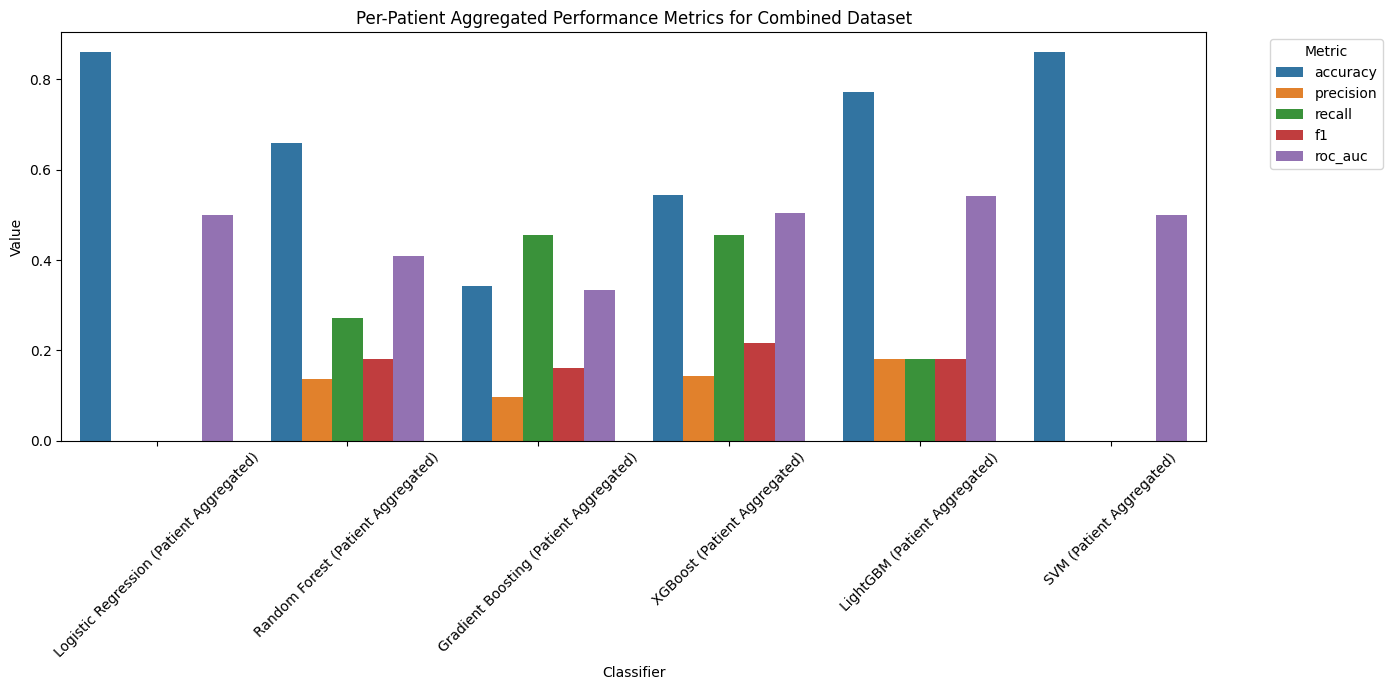

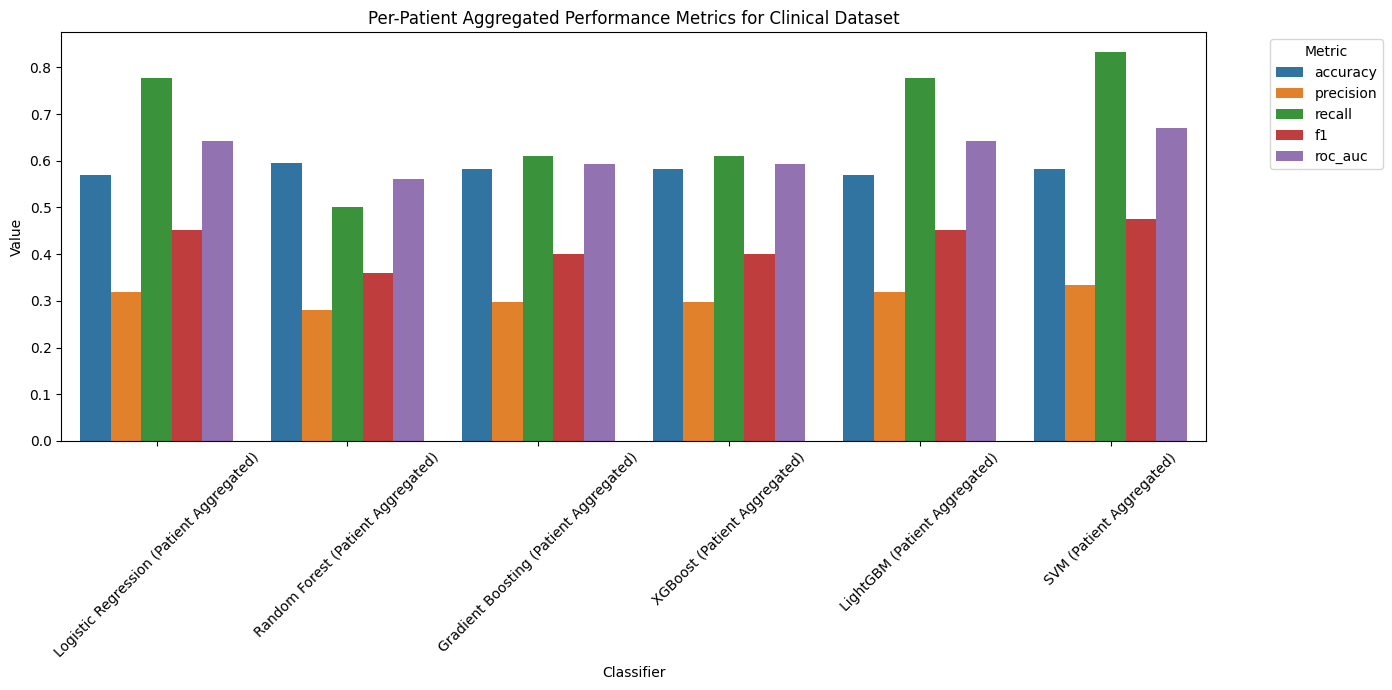

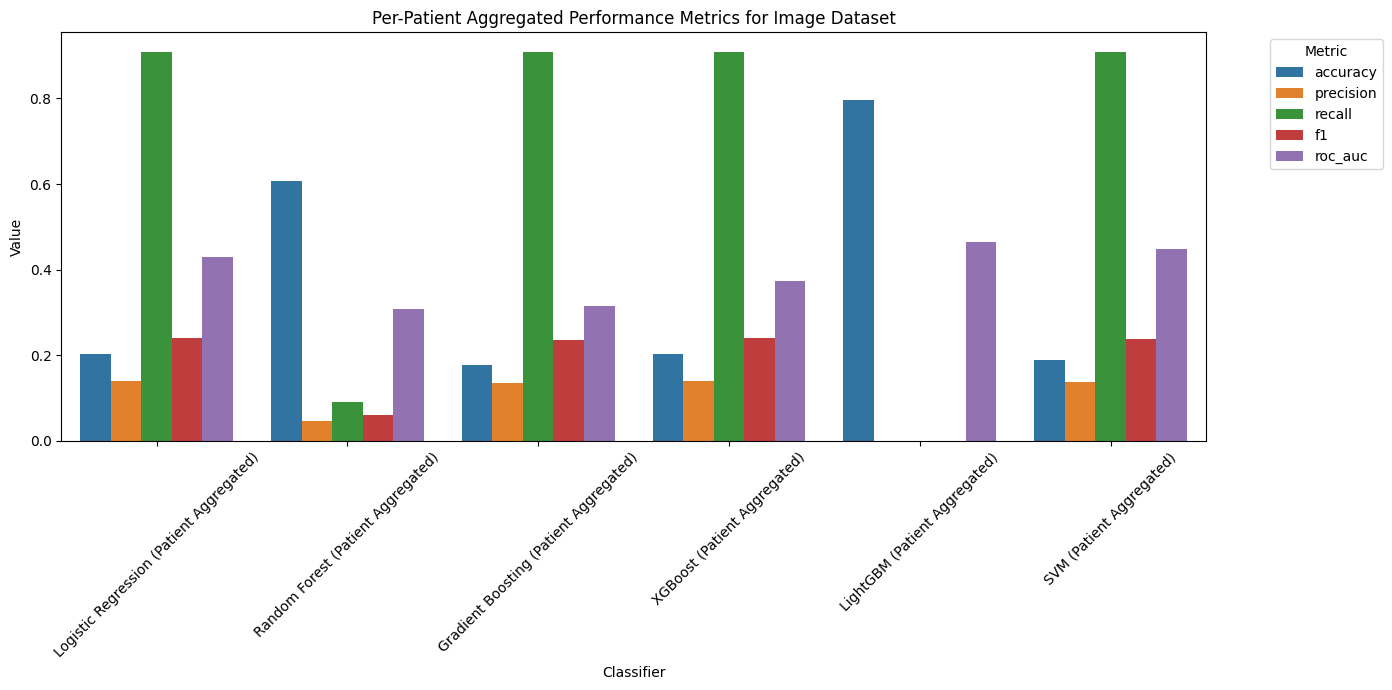

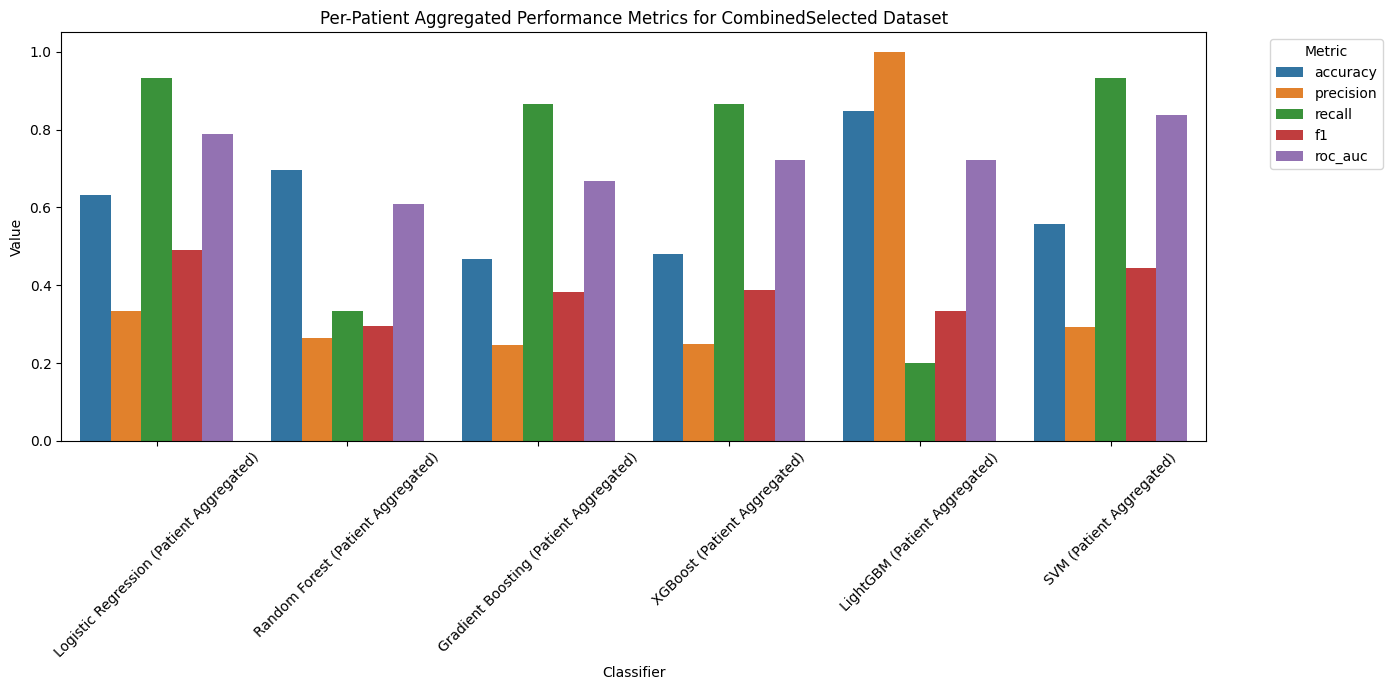

In [151]:
# Visualize Per-Patient Performance Metrics

import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot metrics for each classifier in a dataset
def plot_metrics(dataset_name, classifiers_results):
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    classifier_names = list(classifiers_results.keys())
    metric_values = {metric: [classifiers_results[clf][metric] for clf in classifier_names] for metric in metrics}
    
    df_metrics = pd.DataFrame(metric_values, index=classifier_names)
    df_metrics = df_metrics.reset_index().rename(columns={'index': 'Classifier'})
    
    df_melted = df_metrics.melt(id_vars='Classifier', var_name='Metric', value_name='Value')
    
    plt.figure(figsize=(14, 7))
    sns.barplot(x='Classifier', y='Value', hue='Metric', data=df_melted)
    plt.title(f'Per-Patient Aggregated Performance Metrics for {dataset_name} Dataset')
    plt.xticks(rotation=45)
    plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Plot metrics for each dataset
for dataset_name, classifiers_results in test_results_per_patient.items():
    plot_metrics(dataset_name, classifiers_results)


In [152]:
# Prepare the base classifiers with their best hyperparameters
# Import necessary libraries
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.base import clone
# Prepare the base classifiers with their best hyperparameters
def get_best_classifier(classifier_name, dataset_name):
    # Retrieve the best hyperparameters from nested_cv_results
    nested_results = nested_cv_results[dataset_name]
    cv_results_all = nested_results['cv_results_all']
    cv_results = cv_results_all[classifier_name]
    
    # Find the hyperparameters with the best mean_test_score
    max_mean_test_score = cv_results['mean_test_score'].max()
    best_rows = cv_results[cv_results['mean_test_score'] == max_mean_test_score]
    
    # If multiple rows have the same max score, pick the first one
    best_row = best_rows.iloc[0]
    
    # Extract the best hyperparameters from the pipeline parameters
    best_params = best_row['params']
    
    # The params are for the entire pipeline; extract classifier's hyperparameters
    classifier_params = {}
    for param_name, param_value in best_params.items():
        if param_name.startswith('classifier__'):
            # Remove 'classifier__' prefix to get the parameter name
            param_short = param_name.replace('classifier__', '')
            classifier_params[param_short] = param_value
    
    # Get the default classifier with default parameters
    default_classifier = classifiers[classifier_name]
    
    # Clone the default classifier to avoid modifying the original
    classifier = clone(default_classifier)
    
    # Update the classifier's parameters with the best hyperparameters
    classifier.set_params(**classifier_params)

    # **Compute scale_pos_weight for XGBoost and LightGBM**
    if classifier_name == 'XGBoost' or classifier_name == 'LightGBM':
        scale_pos_weight = (y_train_full == 0).sum() / (y_train_full == 1).sum()
        print(f"Computed scale_pos_weight: {scale_pos_weight:.4f} for {classifier_name}")
        classifier.set_params(scale_pos_weight=scale_pos_weight)
    
    # Handle compatibility between solver and penalty for Logistic Regression
    if classifier_name == 'Logistic Regression':
        penalty = classifier.get_params().get('penalty', 'l2')
        solver = classifier.get_params().get('solver', 'lbfgs')
        if penalty == 'l1' and solver not in ['liblinear', 'saga']:
            # Change solver to 'liblinear' if penalty is 'l1'
            classifier.set_params(solver='liblinear')
            print(f"Adjusted solver to 'liblinear' for 'l1' penalty.")
        elif penalty == 'elasticnet' and solver != 'saga':
            # 'elasticnet' penalty requires 'saga' solver
            classifier.set_params(solver='saga')
            print(f"Adjusted solver to 'saga' for 'elasticnet' penalty.")
        elif penalty == 'l2' and solver == 'liblinear' and classifier.get_params().get('dual', False):
            # Dual formulation is only implemented for l2 penalty with liblinear solver
            classifier.set_params(dual=True)
        else:
            # Ensure dual is False for other solvers
            classifier.set_params(dual=False)
    return classifier


In [153]:
# Function: Create the ensemble classifiers
def create_ensemble_classifiers(dataset_name):
    # Prepare base classifiers
    base_classifiers = []
    classifier_names = ['Logistic Regression','Random Forest', 'XGBoost', 'LightGBM' ,'SVM']
    
    for clf_name in classifier_names:
        clf = get_best_classifier(clf_name, dataset_name)
        base_classifiers.append((clf_name.lower().replace(' ', '_'), clf))
    
    # Create the stacking classifier
    stacking_classifier = StackingClassifier(
        estimators=base_classifiers,
        final_estimator=RandomForestClassifier(random_state=42),
        passthrough=True,
        cv=3,
        n_jobs=-1
    )
    
    # Create the voting classifier
    voting_classifier = VotingClassifier(
        estimators=base_classifiers,
        voting='soft',  # Use 'hard' for majority voting
        #weights=[1, 1, 1],  # Uniform weights 
        n_jobs=-1
    )
    
    return stacking_classifier, voting_classifier

In [154]:
# Retrain and test on Ensemble Classifiers
test_results_ensemble = {}

for dataset_name in data_splits.keys():
    print(f"\nEvaluating Ensemble Classifiers on '{dataset_name}' Dataset")
    
    # Retrieve data splits for the current dataset
    data = data_splits[dataset_name]
    X_train_full = data['X_train_full']
    y_train_full = data['y_train_full']
    X_test_full = data['X_test_full']
    y_test = data['y_test']
    patient_ids_test = data['patient_ids_test'].reset_index(drop=True)
    
    # Create a DataFrame for test data
    test_df = X_test_full.copy()
    test_df['y_true'] = y_test.values
    test_df['patient_id'] = pd.Series(patient_ids_test, index=test_df.index)
    
    # Get per-patient true labels (assuming all slices of a patient have the same label)
    y_true_per_patient = test_df.groupby('patient_id')['y_true'].first()
    
    # Create ensemble classifiers
    stacking_classifier, voting_classifier = create_ensemble_classifiers(dataset_name)
    
    ensemble_classifiers = {
        'Stacking Classifier': stacking_classifier,
        'Voting Classifier': voting_classifier
    }
    
    for ensemble_name, ensemble_clf in ensemble_classifiers.items():
        print(f"\nClassifier: {ensemble_name}")
        
        # Handle classifiers that do not support predict
        if not hasattr(ensemble_clf, "predict"):
            print(f"Classifier '{ensemble_name}' does not support predict method. Skipping.")
            continue
        
        # Apply SMOTE to training data only
        #print("\nApplying SMOTE to balance the classes in the training data...")
        #smote = SMOTE(random_state=42)
        #X_train_resampled, y_train_resampled = smote.fit_resample(X_train_full, y_train_full)
        
        # Define the pipeline without SMOTE
        pipeline = Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('classifier', ensemble_clf)
        ])
        
        # Fit the pipeline on the entire training set
        pipeline.fit(X_train_full, y_train_full)
        
        # Predict on the test set
        y_pred = pipeline.predict(X_test_full)
        
        # Get predicted probabilities if available
        y_proba = pipeline.predict_proba(X_test_full)[:, 1] if hasattr(pipeline, "predict_proba") else None
        
        # Compute performance metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
        conf_matrix = confusion_matrix(y_test, y_pred)
        class_report = classification_report(y_test, y_pred, zero_division=0)
        
        # Store the results
        test_results_ensemble[dataset_name] = test_results_ensemble.get(dataset_name, {})
        test_results_ensemble[dataset_name][ensemble_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'confusion_matrix': conf_matrix,
            'classification_report': class_report
        }
        
        # Print the results
        print(f"\nAggregated Test Results for {ensemble_name} on {dataset_name} Dataset:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        if roc_auc is not None:
            print(f"ROC AUC Score: {roc_auc:.4f}")
        print("Confusion Matrix:")
        print(conf_matrix)
        print("Classification Report:")
        print(class_report)



Evaluating Ensemble Classifiers on 'Combined' Dataset
Computed scale_pos_weight: 0.8441 for XGBoost
Computed scale_pos_weight: 0.8441 for LightGBM

Classifier: Stacking Classifier
[LightGBM] [Info] Number of positive: 1668, number of negative: 1408
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002887 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7095
[LightGBM] [Info] Number of data points in the train set: 3076, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 1112, number of negative: 939
[LightGBM] [Info] Number of positive: 1112, number of negative: 938
[LightGBM] [Info] Number of positive: 1112, number of negative: 939
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006784 seconds.
You can set `force_col

In [155]:
# Bootstrap Confidence Intervals for Test Metrics

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Number of bootstrap iterations
n_bootstraps = 1000
rng = np.random.RandomState(seed=42)  # For reproducibility

# Initialize a dictionary to store bootstrap results
bootstrap_results = {}

for dataset_name in data_splits.keys():
    print(f"\nBootstrapping Test Metrics for '{dataset_name}' Dataset")
    
    # Retrieve data splits for the current dataset
    data = data_splits[dataset_name]
    X_test_full = data['X_test_full']
    y_test = data['y_test'].reset_index(drop=True)
    
    # Initialize dictionary for classifiers
    bootstrap_results[dataset_name] = {}
    
    for classifier_name in classifiers.keys():
        print(f"\nClassifier: {classifier_name}")
        
        # Retrieve the best hyperparameters from nested_cv_results
        nested_results = nested_cv_results[dataset_name]
        cv_results_all = nested_results['cv_results_all']
        cv_results = cv_results_all[classifier_name]
        
        # Find the hyperparameters with the best mean_test_score
        max_mean_test_score = cv_results['mean_test_score'].max()
        best_rows = cv_results[cv_results['mean_test_score'] == max_mean_test_score]
        
        # If multiple rows have the same max score, pick the first one
        best_row = best_rows.iloc[0]
        
        # Extract the best hyperparameters from the pipeline parameters
        best_params = best_row['params']
        
        # The params are for the entire pipeline; extract classifier's hyperparameters
        classifier_params = {}
        for param_name, param_value in best_params.items():
            if param_name.startswith('classifier__'):
                # Remove 'classifier__' prefix to get the parameter name
                param_short = param_name.replace('classifier__', '')
                classifier_params[param_short] = param_value
        
        # Get the default classifier with default parameters
        default_classifier = classifiers[classifier_name]
        
        # Clone the default classifier to avoid modifying the original
        classifier = clone(default_classifier)
        
        # Update the classifier's parameters with the best hyperparameters
        classifier.set_params(**classifier_params)
        
        # **Compute scale_pos_weight for XGBoost and LightGBM**
        if classifier_name == 'XGBoost' or classifier_name == 'LightGBM':
            scale_pos_weight = (y_train_full == 0).sum() / (y_train_full == 1).sum()
            print(f"Computed scale_pos_weight: {scale_pos_weight:.4f} for {classifier_name}")
            classifier.set_params(scale_pos_weight=scale_pos_weight)

        # Handle compatibility between solver and penalty for Logistic Regression
        if classifier_name == 'Logistic Regression':
            penalty = classifier.get_params().get('penalty', 'l2')
            solver = classifier.get_params().get('solver', 'lbfgs')
            if penalty == 'l1' and solver not in ['liblinear', 'saga']:
                # Change solver to 'liblinear' if penalty is 'l1'
                classifier.set_params(solver='liblinear')
                print(f"Adjusted solver to 'liblinear' for 'l1' penalty.")
            elif penalty == 'elasticnet' and solver != 'saga':
                # 'elasticnet' penalty requires 'saga' solver
                classifier.set_params(solver='saga')
                print(f"Adjusted solver to 'saga' for 'elasticnet' penalty.")
            elif penalty == 'l2' and solver == 'liblinear' and classifier.get_params().get('dual', False):
                # Dual formulation is only implemented for l2 penalty with liblinear solver
                classifier.set_params(dual=True)
            else:
                # Ensure dual is False for other solvers
                classifier.set_params(dual=False)
        
        # Retrieve training data
        X_train_full = data['X_train_full']
        y_train_full = data['y_train_full']
        
        # Apply SMOTE to training data only
        #print("\nApplying SMOTE to balance the classes in the training data...")
        #smote = SMOTE(random_state=42)
        #X_train_resampled, y_train_resampled = smote.fit_resample(X_train_full, y_train_full)
        
        # Define the pipeline without SMOTE
        pipeline = Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('classifier', classifier)
        ])
        
        # Fit the pipeline on the entire training set
        pipeline.fit(X_train_full, y_train_full)
        
        # Initialize lists to store bootstrap metrics
        bootstrap_accuracies = []
        bootstrap_precisions = []
        bootstrap_recalls = []
        bootstrap_f1s = []
        bootstrap_roc_aucs = []
        
        # Convert y_test to numpy array
        y_test_array = y_test.values
        
        # Compute predicted probabilities once (since the model is fixed)
        if hasattr(pipeline.named_steps['classifier'], "predict_proba"):
            y_proba_full = pipeline.predict_proba(X_test_full)[:, 1]
        else:
            # For classifiers that do not have predict_proba, skip ROC AUC
            y_proba_full = None
        
        # Perform bootstrap resampling
        for i in range(n_bootstraps):
            # Sample indices with replacement
            indices = rng.choice(len(X_test_full), size=len(X_test_full), replace=True)
            X_test_bootstrap = X_test_full.iloc[indices]
            y_test_bootstrap = y_test_array[indices]
            
            # Make predictions on the bootstrap sample
            y_pred_bootstrap = pipeline.predict(X_test_bootstrap)
            
            # Compute metrics
            accuracy = accuracy_score(y_test_bootstrap, y_pred_bootstrap)
            precision = precision_score(y_test_bootstrap, y_pred_bootstrap, zero_division=0)
            recall = recall_score(y_test_bootstrap, y_pred_bootstrap)
            f1 = f1_score(y_test_bootstrap, y_pred_bootstrap)
            if y_proba_full is not None:
                y_proba_bootstrap = y_proba_full[indices]
                roc_auc = roc_auc_score(y_test_bootstrap, y_proba_bootstrap)
            else:
                roc_auc = np.nan  # Not available for this classifier
                
            # Append metrics
            bootstrap_accuracies.append(accuracy)
            bootstrap_precisions.append(precision)
            bootstrap_recalls.append(recall)
            bootstrap_f1s.append(f1)
            bootstrap_roc_aucs.append(roc_auc)
        
        # Compute confidence intervals (e.g., 95% CI)
        def compute_confidence_interval(metric_values):
            sorted_values = np.sort(metric_values)
            lower = np.percentile(sorted_values, 2.5)
            upper = np.percentile(sorted_values, 97.5)
            mean = np.mean(metric_values)
            return mean, lower, upper
        
        accuracy_mean, accuracy_lower, accuracy_upper = compute_confidence_interval(bootstrap_accuracies)
        precision_mean, precision_lower, precision_upper = compute_confidence_interval(bootstrap_precisions)
        recall_mean, recall_lower, recall_upper = compute_confidence_interval(bootstrap_recalls)
        f1_mean, f1_lower, f1_upper = compute_confidence_interval(bootstrap_f1s)
        roc_auc_mean, roc_auc_lower, roc_auc_upper = compute_confidence_interval(bootstrap_roc_aucs)
        
        # Store the bootstrap results
        bootstrap_results[dataset_name][classifier_name] = {
            'accuracy': (accuracy_mean, accuracy_lower, accuracy_upper),
            'precision': (precision_mean, precision_lower, precision_upper),
            'recall': (recall_mean, recall_lower, recall_upper),
            'f1': (f1_mean, f1_lower, f1_upper),
            'roc_auc': (roc_auc_mean, roc_auc_lower, roc_auc_upper),
        }
        
        # Print the results
        print(f"{classifier_name} Bootstrap Confidence Intervals:")
        print(f"Accuracy: {accuracy_mean:.4f} (95% CI: {accuracy_lower:.4f} - {accuracy_upper:.4f})")
        print(f"Precision: {precision_mean:.4f} (95% CI: {precision_lower:.4f} - {precision_upper:.4f})")
        print(f"Recall: {recall_mean:.4f} (95% CI: {recall_lower:.4f} - {recall_upper:.4f})")
        print(f"F1 Score: {f1_mean:.4f} (95% CI: {f1_lower:.4f} - {f1_upper:.4f})")
        if not np.isnan(roc_auc_mean):
            print(f"ROC AUC: {roc_auc_mean:.4f} (95% CI: {roc_auc_lower:.4f} - {roc_auc_upper:.4f})")
        else:
            print("ROC AUC: Not available for this classifier")



Bootstrapping Test Metrics for 'Combined' Dataset

Classifier: Logistic Regression
Logistic Regression Bootstrap Confidence Intervals:
Accuracy: 0.7714 (95% CI: 0.7587 - 0.7829)
Precision: 0.0000 (95% CI: 0.0000 - 0.0000)
Recall: 0.0000 (95% CI: 0.0000 - 0.0000)
F1 Score: 0.0000 (95% CI: 0.0000 - 0.0000)
ROC AUC: 0.5000 (95% CI: 0.5000 - 0.5000)

Classifier: Random Forest
Random Forest Bootstrap Confidence Intervals:
Accuracy: 0.3618 (95% CI: 0.3480 - 0.3749)
Precision: 0.2399 (95% CI: 0.2259 - 0.2535)
Recall: 0.8279 (95% CI: 0.8041 - 0.8492)
F1 Score: 0.3720 (95% CI: 0.3544 - 0.3888)
ROC AUC: 0.5472 (95% CI: 0.5284 - 0.5663)

Classifier: Gradient Boosting
Gradient Boosting Bootstrap Confidence Intervals:
Accuracy: 0.3764 (95% CI: 0.3628 - 0.3900)
Precision: 0.2387 (95% CI: 0.2250 - 0.2522)
Recall: 0.7902 (95% CI: 0.7672 - 0.8144)
F1 Score: 0.3665 (95% CI: 0.3492 - 0.3833)
ROC AUC: 0.4745 (95% CI: 0.4567 - 0.4927)

Classifier: XGBoost
Computed scale_pos_weight: 0.8441 for XGBoost
XGBo

In [156]:
# Bootstrap Confidence Intervals with Patient-Level and Slice-Level Thresholding

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.base import clone

# Number of bootstrap iterations
n_bootstraps = 1000
rng = np.random.RandomState(seed=42)  # For reproducibility

# Initialize a dictionary to store bootstrap results
bootstrap_results_per_patient = {}

for dataset_name in data_splits.keys():
    print(f"\nBootstrapping Test Metrics for '{dataset_name}' Dataset")
    
    # Retrieve data splits for the current dataset
    data = data_splits[dataset_name]
    X_test_full = data['X_test_full'].reset_index(drop=True)
    y_test = data['y_test'].reset_index(drop=True)
    patient_ids_test = data['patient_ids_test'].reset_index(drop=True)
    
    # Combine test data into a single DataFrame
    test_df = X_test_full.copy()
    test_df['y_true'] = y_test
    test_df['patient_id'] = patient_ids_test
    
    # Get unique patient IDs
    unique_patient_ids = test_df['patient_id'].unique()
    
    # Initialize dictionary for classifiers
    bootstrap_results_per_patient[dataset_name] = {}
    
    for classifier_name in classifiers.keys():
        print(f"\nClassifier: {classifier_name}")
        
        # Retrieve the best hyperparameters from nested_cv_results
        nested_results = nested_cv_results[dataset_name]
        cv_results_all = nested_results['cv_results_all']
        cv_results = cv_results_all[classifier_name]
        
        # Find the hyperparameters with the best mean_test_score
        max_mean_test_score = cv_results['mean_test_score'].max()
        best_rows = cv_results[cv_results['mean_test_score'] == max_mean_test_score]
        
        # If multiple rows have the same max score, pick the first one
        best_row = best_rows.iloc[0]
        
        # Extract the best hyperparameters from the pipeline parameters
        best_params = best_row['params']
        
        # The params are for the entire pipeline; extract classifier's hyperparameters
        classifier_params = {}
        for param_name, param_value in best_params.items():
            if param_name.startswith('classifier__'):
                # Remove 'classifier__' prefix to get the parameter name
                param_short = param_name.replace('classifier__', '')
                classifier_params[param_short] = param_value
        
        # Get the default classifier with default parameters
        default_classifier = classifiers[classifier_name]
        
        # Clone the default classifier to avoid modifying the original
        classifier = clone(default_classifier)
        
        # Update the classifier's parameters with the best hyperparameters
        classifier.set_params(**classifier_params)

        # **Compute scale_pos_weight for XGBoost and LightGBM**
        if classifier_name == 'XGBoost' or classifier_name == 'LightGBM':
            scale_pos_weight = (y_train_full == 0).sum() / (y_train_full == 1).sum()
            print(f"Computed scale_pos_weight: {scale_pos_weight:.4f} for {classifier_name}")
            classifier.set_params(scale_pos_weight=scale_pos_weight)
        
        # Handle compatibility between solver and penalty for Logistic Regression
        if classifier_name == 'Logistic Regression':
            penalty = classifier.get_params().get('penalty', 'l2')
            solver = classifier.get_params().get('solver', 'lbfgs')
            if penalty == 'l1' and solver not in ['liblinear', 'saga']:
                # Change solver to 'liblinear' if penalty is 'l1'
                classifier.set_params(solver='liblinear')
                print(f"Adjusted solver to 'liblinear' for 'l1' penalty.")
            elif penalty == 'elasticnet' and solver != 'saga':
                # 'elasticnet' penalty requires 'saga' solver
                classifier.set_params(solver='saga')
                print(f"Adjusted solver to 'saga' for 'elasticnet' penalty.")
            elif penalty == 'l2' and solver == 'liblinear' and classifier.get_params().get('dual', False):
                # Dual formulation is only implemented for l2 penalty with liblinear solver
                classifier.set_params(dual=True)
            else:
                # Ensure dual is False for other solvers
                classifier.set_params(dual=False)
        
        # Retrieve training data
        X_train_full = data['X_train_full']
        y_train_full = data['y_train_full']
        
        # Apply SMOTE to training data only
        #print("\nApplying SMOTE to balance the classes in the training data...")
        #smote = SMOTE(random_state=42)
        #X_train_resampled, y_train_resampled = smote.fit_resample(X_train_full, y_train_full)
        
        # Define the pipeline without SMOTE
        pipeline = Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('classifier', classifier)
        ])
        
        # Fit the pipeline on the entire training set
        pipeline.fit(X_train_full, y_train_full)
        
        # Compute predicted probabilities on the full test set
        if hasattr(pipeline.named_steps['classifier'], "predict_proba"):
            y_proba_full = pipeline.predict_proba(X_test_full)[:, 1]
        else:
            print(f"Classifier '{classifier_name}' does not support probability estimates. Skipping.")
            continue
        
        # Add predicted probabilities to test_df
        test_df['y_proba'] = y_proba_full
        
        # Initialize lists to store bootstrap metrics
        bootstrap_accuracies = []
        bootstrap_precisions = []
        bootstrap_recalls = []
        bootstrap_f1s = []
        bootstrap_roc_aucs = []

        # Compute predicted probabilities on training data
        y_proba_train = pipeline.predict_proba(X_train_full)[:, 1]
        
        # Create train_df similar to test_df
        train_df = X_train_full.copy()
        train_df['y_true'] = y_train_full.values
        
        # Number of original samples before SMOTE
        n_original_samples = len(X_train_full)
        
        # Assign patient IDs to original samples
        train_df.loc[:n_original_samples - 1, 'patient_id'] = data['patient_ids_train'].values
        
        # Number of synthetic samples added by SMOTE
        n_synthetic_samples = len(X_train_full) - n_original_samples
        
        # Identify the minority class in the original training data
        minority_class = y_train_full.value_counts().idxmin()
        
        # Get indices and patient IDs of minority class samples
        minority_indices = y_train_full[y_train_full == minority_class].index
        minority_patient_ids = data['patient_ids_train'].loc[minority_indices].values
        
        # Randomly assign patient IDs from minority class to synthetic samples
        synthetic_patient_ids = np.random.choice(
            minority_patient_ids, size=n_synthetic_samples, replace=True
        )
        
        # Assign patient IDs to synthetic samples
        train_df.loc[n_original_samples:, 'patient_id'] = synthetic_patient_ids
        
        # Ensure the 'patient_id' column is of the correct data type
        train_df['patient_id'] = train_df['patient_id'].astype(data['patient_ids_train'].dtype)



        train_df['y_proba'] = y_proba_train
        
        # Compute optimal slice_threshold using training data
        slice_threshold = find_optimal_threshold(train_df['y_true'], train_df['y_proba'])
        print(f"Optimal Slice Threshold (Youden's J) from training data: {slice_threshold:.4f}")
        
        # Assign per-slice predictions on training data
        train_df['y_pred_slice'] = (train_df['y_proba'] >= slice_threshold).astype(int)
        
        # Aggregate predictions per patient in training data
        slice_proportions_train = train_df.groupby('patient_id')['y_pred_slice'].mean()
        y_true_per_patient_train = train_df.groupby('patient_id')['y_true'].first()
        
        # Compute patient_threshold using training data
        patient_threshold = find_optimal_threshold(y_true_per_patient_train, slice_proportions_train)
        print(f"Optimal Patient Threshold (Youden's J) from training data: {patient_threshold:.4f}")

        
        # Perform bootstrap resampling
        for i in range(n_bootstraps):
            # Sample patient IDs with replacement
            sampled_patient_ids = rng.choice(unique_patient_ids, size=len(unique_patient_ids), replace=True)
            
            # Get the indices of the slices corresponding to the sampled patient IDs
            sampled_indices = test_df[test_df['patient_id'].isin(sampled_patient_ids)].index
            
            # Create bootstrap sample
            test_df_bootstrap = test_df.loc[sampled_indices].reset_index(drop=True)
            
            # Get true labels and predicted probabilities
            y_true_bootstrap = test_df_bootstrap['y_true']
            y_proba_bootstrap = test_df_bootstrap['y_proba']
            
            # Use the thresholds computed from training data
            # Apply optimal slice threshold
            test_df_bootstrap['y_pred_slice'] = (test_df_bootstrap['y_proba'] >= slice_threshold).astype(int)

            # Aggregate predictions per patient
            slice_proportions = test_df_bootstrap.groupby('patient_id')['y_pred_slice'].mean()
            y_true_per_patient_bootstrap = test_df_bootstrap.groupby('patient_id')['y_true'].first()

            # Apply optimal patient threshold
            y_pred_per_patient_bootstrap = (slice_proportions >= patient_threshold).astype(int)

            # Compute performance metrics at the patient level
            accuracy = accuracy_score(y_true_per_patient_bootstrap, y_pred_per_patient_bootstrap)
            precision = precision_score(y_true_per_patient_bootstrap, y_pred_per_patient_bootstrap, zero_division=0)
            recall = recall_score(y_true_per_patient_bootstrap, y_pred_per_patient_bootstrap)
            f1 = f1_score(y_true_per_patient_bootstrap, y_pred_per_patient_bootstrap)
            roc_auc = roc_auc_score(y_true_per_patient_bootstrap, slice_proportions)
            
            # Append metrics
            bootstrap_accuracies.append(accuracy)
            bootstrap_precisions.append(precision)
            bootstrap_recalls.append(recall)
            bootstrap_f1s.append(f1)
            bootstrap_roc_aucs.append(roc_auc)
        
        # Compute confidence intervals (e.g., 95% CI)
        def compute_confidence_interval(metric_values):
            sorted_values = np.sort(metric_values)
            lower = np.percentile(sorted_values, 2.5)
            upper = np.percentile(sorted_values, 97.5)
            mean = np.mean(metric_values)
            return mean, lower, upper
        
        accuracy_mean, accuracy_lower, accuracy_upper = compute_confidence_interval(bootstrap_accuracies)
        precision_mean, precision_lower, precision_upper = compute_confidence_interval(bootstrap_precisions)
        recall_mean, recall_lower, recall_upper = compute_confidence_interval(bootstrap_recalls)
        f1_mean, f1_lower, f1_upper = compute_confidence_interval(bootstrap_f1s)
        roc_auc_mean, roc_auc_lower, roc_auc_upper = compute_confidence_interval(bootstrap_roc_aucs)
        
        # Store the bootstrap results
        bootstrap_results_per_patient[dataset_name][classifier_name] = {
            'accuracy': (accuracy_mean, accuracy_lower, accuracy_upper),
            'precision': (precision_mean, precision_lower, precision_upper),
            'recall': (recall_mean, recall_lower, recall_upper),
            'f1': (f1_mean, f1_lower, f1_upper),
            'roc_auc': (roc_auc_mean, roc_auc_lower, roc_auc_upper),
        }
        
        # Print the results
        print(f"\n{classifier_name} Bootstrap Confidence Intervals (Patient-Level):")
        print(f"Accuracy: {accuracy_mean:.4f} (95% CI: {accuracy_lower:.4f} - {accuracy_upper:.4f})")
        print(f"Precision: {precision_mean:.4f} (95% CI: {precision_lower:.4f} - {precision_upper:.4f})")
        print(f"Recall: {recall_mean:.4f} (95% CI: {recall_lower:.4f} - {recall_upper:.4f})")
        print(f"F1 Score: {f1_mean:.4f} (95% CI: {f1_lower:.4f} - {f1_upper:.4f})")
        print(f"ROC AUC: {roc_auc_mean:.4f} (95% CI: {roc_auc_lower:.4f} - {roc_auc_upper:.4f})")



Bootstrapping Test Metrics for 'Combined' Dataset

Classifier: Logistic Regression
Optimal Slice Threshold (Youden's J) from training data: 0.4812
Optimal Patient Threshold (Youden's J) from training data: 0.6500

Logistic Regression Bootstrap Confidence Intervals (Patient-Level):
Accuracy: 0.8613 (95% CI: 0.8070 - 0.9231)
Precision: 0.0000 (95% CI: 0.0000 - 0.0000)
Recall: 0.0000 (95% CI: 0.0000 - 0.0000)
F1 Score: 0.0000 (95% CI: 0.0000 - 0.0000)
ROC AUC: 0.5000 (95% CI: 0.5000 - 0.5000)

Classifier: Random Forest
Optimal Slice Threshold (Youden's J) from training data: 0.5218
Optimal Patient Threshold (Youden's J) from training data: 0.8500

Random Forest Bootstrap Confidence Intervals (Patient-Level):
Accuracy: 0.6580 (95% CI: 0.5769 - 0.7400)
Precision: 0.1361 (95% CI: 0.0000 - 0.2500)
Recall: 0.2713 (95% CI: 0.0000 - 0.5000)
F1 Score: 0.1786 (95% CI: 0.0000 - 0.3000)
ROC AUC: 0.4079 (95% CI: 0.2522 - 0.5630)

Classifier: Gradient Boosting
Optimal Slice Threshold (Youden's J) fro

In [157]:
# =================== Bootstrap Confidence Intervals for Ensemble Classifiers without Thresholding ===================

# Number of bootstrap iterations
n_bootstraps = 1000
rng = np.random.RandomState(seed=42)  # For reproducibility

# Initialize a dictionary to store bootstrap results
bootstrap_results_ensemble = {}

for dataset_name in data_splits.keys():
    print(f"\nBootstrapping Test Metrics for Ensemble Classifiers on '{dataset_name}' Dataset")
    
    # Retrieve data splits for the current dataset
    data = data_splits[dataset_name]
    X_test_full = data['X_test_full'].reset_index(drop=True)
    y_test = data['y_test'].reset_index(drop=True)
    patient_ids_test = data['patient_ids_test'].reset_index(drop=True)
    
    # Combine test data into a single DataFrame
    test_df = X_test_full.copy()
    test_df['y_true'] = y_test.values
    test_df['patient_id'] = pd.Series(patient_ids_test, index=test_df.index)
    


    # Get unique patient IDs
    unique_patient_ids = test_df['patient_id'].unique()
    n_patients = len(unique_patient_ids)
    
    # Create ensemble classifiers
    stacking_classifier, voting_classifier = create_ensemble_classifiers(dataset_name)
    
    ensemble_classifiers = {
        'Stacking Classifier': stacking_classifier,
        'Voting Classifier': voting_classifier
    }
    
    for ensemble_name, ensemble_clf in ensemble_classifiers.items():
        print(f"\nClassifier: {ensemble_name}")
        
        # Ensure Voting Classifier uses soft voting and supports predict_proba
        if not hasattr(ensemble_clf, "predict_proba"):
            print(f"Classifier '{ensemble_name}' does not support probability estimates. Skipping.")
            continue
        
        # Define the pipeline without SMOTE
        pipeline = Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('classifier', ensemble_clf)
        ])
        
        # Fit the pipeline on the entire training set
        pipeline.fit(data['X_train_full'], data['y_train_full'])
        
        # Compute predicted probabilities on the full test set
        y_proba_full = pipeline.predict_proba(X_test_full)[:, 1]
        
        # Add predicted probabilities to test_df
        test_df['y_proba'] = y_proba_full
        
        # Initialize lists to store bootstrap metrics
        bootstrap_accuracies = []
        bootstrap_precisions = []
        bootstrap_recalls = []
        bootstrap_f1s = []
        bootstrap_roc_aucs = []
        
        # Precompute per-slice predictions to speed up
        y_pred_slice = pipeline.predict(X_test_full)
        test_df['y_pred_slice'] = y_pred_slice
        
        # Perform bootstrap resampling with progress bar
        for i in tqdm(range(n_bootstraps), desc=f"Bootstrapping {ensemble_name}", leave=False):
            # Sample patient IDs with replacement
            sampled_patient_ids = rng.choice(unique_patient_ids, size=n_patients, replace=True)
            
            # Create a mask for sampled patients
            mask = test_df['patient_id'].isin(sampled_patient_ids)
            test_df_bootstrap = test_df[mask].reset_index(drop=True)
            
            # Aggregate per-slice predictions per patient using majority vote
            y_pred_per_patient_bootstrap = test_df_bootstrap.groupby('patient_id')['y_pred_slice'].agg(lambda x: x.value_counts().idxmax())
            y_true_per_patient_bootstrap = test_df_bootstrap.groupby('patient_id')['y_true'].first()
            
            # Aggregate per-slice probabilities per patient (mean)
            per_patient_proba = test_df_bootstrap.groupby('patient_id')['y_proba'].mean()
            
            # Compute performance metrics at the patient level
            accuracy = accuracy_score(y_true_per_patient_bootstrap, y_pred_per_patient_bootstrap)
            precision = precision_score(y_true_per_patient_bootstrap, y_pred_per_patient_bootstrap, zero_division=0)
            recall = recall_score(y_true_per_patient_bootstrap, y_pred_per_patient_bootstrap, zero_division=0)
            f1 = f1_score(y_true_per_patient_bootstrap, y_pred_per_patient_bootstrap, zero_division=0)
            roc_auc = roc_auc_score(y_true_per_patient_bootstrap, per_patient_proba)
            
            # Append metrics
            bootstrap_accuracies.append(accuracy)
            bootstrap_precisions.append(precision)
            bootstrap_recalls.append(recall)
            bootstrap_f1s.append(f1)
            bootstrap_roc_aucs.append(roc_auc)
        
        # Compute confidence intervals (e.g., 95% CI)
        def compute_confidence_interval(metric_values):
            sorted_values = np.sort(metric_values)
            lower = np.percentile(sorted_values, 2.5)
            upper = np.percentile(sorted_values, 97.5)
            mean = np.mean(metric_values)
            return mean, lower, upper
        
        accuracy_mean, accuracy_lower, accuracy_upper = compute_confidence_interval(bootstrap_accuracies)
        precision_mean, precision_lower, precision_upper = compute_confidence_interval(bootstrap_precisions)
        recall_mean, recall_lower, recall_upper = compute_confidence_interval(bootstrap_recalls)
        f1_mean, f1_lower, f1_upper = compute_confidence_interval(bootstrap_f1s)
        roc_auc_mean, roc_auc_lower, roc_auc_upper = compute_confidence_interval(bootstrap_roc_aucs)
        
        # Store the bootstrap results
        bootstrap_results_ensemble[dataset_name] = bootstrap_results_ensemble.get(dataset_name, {})
        bootstrap_results_ensemble[dataset_name][ensemble_name] = {
            'accuracy': (accuracy_mean, accuracy_lower, accuracy_upper),
            'precision': (precision_mean, precision_lower, precision_upper),
            'recall': (recall_mean, recall_lower, recall_upper),
            'f1': (f1_mean, f1_lower, f1_upper),
            'roc_auc': (roc_auc_mean, roc_auc_lower, roc_auc_upper),
        }
        
        # Print the results
        print(f"\n{ensemble_name} Bootstrap Confidence Intervals (Patient-Level):")
        print(f"Accuracy: {accuracy_mean:.4f} (95% CI: {accuracy_lower:.4f} - {accuracy_upper:.4f})")
        print(f"Precision: {precision_mean:.4f} (95% CI: {precision_lower:.4f} - {precision_upper:.4f})")
        print(f"Recall: {recall_mean:.4f} (95% CI: {recall_lower:.4f} - {recall_upper:.4f})")
        print(f"F1 Score: {f1_mean:.4f} (95% CI: {f1_lower:.4f} - {f1_upper:.4f})")
        print(f"ROC AUC: {roc_auc_mean:.4f} (95% CI: {roc_auc_lower:.4f} - {roc_auc_upper:.4f})")
# ===================================================================================


Bootstrapping Test Metrics for Ensemble Classifiers on 'Combined' Dataset
Computed scale_pos_weight: 0.8401 for XGBoost
Computed scale_pos_weight: 0.8401 for LightGBM

Classifier: Stacking Classifier
[LightGBM] [Info] Number of positive: 1668, number of negative: 1408
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029788 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7095
[LightGBM] [Info] Number of data points in the train set: 3076, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 1112, number of negative: 938
[LightGBM] [Info] Number of positive: 1112, number of negative: 939
[LightGBM] [Info] Number of positive: 1112, number of negative: 939
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004563 seconds.
Yo


Stacking Classifier Bootstrap Confidence Intervals (Patient-Level):
Accuracy: 0.3930 (95% CI: 0.3077 - 0.4773)
Precision: 0.1861 (95% CI: 0.1053 - 0.2619)
Recall: 1.0000 (95% CI: 1.0000 - 1.0000)
F1 Score: 0.3119 (95% CI: 0.1905 - 0.4151)
ROC AUC: 0.5452 (95% CI: 0.4185 - 0.6858)

Classifier: Voting Classifier
[LightGBM] [Info] Number of positive: 1668, number of negative: 1408
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003509 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7095
[LightGBM] [Info] Number of data points in the train set: 3076, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000



Voting Classifier Bootstrap Confidence Intervals (Patient-Level):
Accuracy: 0.3404 (95% CI: 0.2600 - 0.4200)
Precision: 0.1525 (95% CI: 0.0833 - 0.2163)
Recall: 0.8202 (95% CI: 0.6667 - 1.0000)
F1 Score: 0.2556 (95% CI: 0.1500 - 0.3500)
ROC AUC: 0.4915 (95% CI: 0.3333 - 0.6482)

Bootstrapping Test Metrics for Ensemble Classifiers on 'Clinical' Dataset
Computed scale_pos_weight: 0.8401 for XGBoost
Computed scale_pos_weight: 0.8401 for LightGBM

Classifier: Stacking Classifier
[LightGBM] [Info] Number of positive: 42, number of negative: 141
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000409 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10
[LightGBM] [Info] Number of data points in the train set: 183, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start tr


Stacking Classifier Bootstrap Confidence Intervals (Patient-Level):
Accuracy: 0.7108 (95% CI: 0.6326 - 0.7917)
Precision: 0.0000 (95% CI: 0.0000 - 0.0000)
Recall: 0.0000 (95% CI: 0.0000 - 0.0000)
F1 Score: 0.0000 (95% CI: 0.0000 - 0.0000)
ROC AUC: 0.5938 (95% CI: 0.4954 - 0.6979)

Classifier: Voting Classifier
[LightGBM] [Info] Number of positive: 42, number of negative: 141
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000293 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10
[LightGBM] [Info] Number of data points in the train set: 183, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga


Voting Classifier Bootstrap Confidence Intervals (Patient-Level):
Accuracy: 0.7718 (95% CI: 0.7059 - 0.8400)
Precision: 0.4852 (95% CI: 0.0000 - 1.0000)
Recall: 0.1090 (95% CI: 0.0000 - 0.2222)
F1 Score: 0.1738 (95% CI: 0.0000 - 0.3077)
ROC AUC: 0.6792 (95% CI: 0.5738 - 0.7786)

Bootstrapping Test Metrics for Ensemble Classifiers on 'Image' Dataset
Computed scale_pos_weight: 0.8401 for XGBoost
Computed scale_pos_weight: 0.8401 for LightGBM

Classifier: Stacking Classifier
[LightGBM] [Info] Number of positive: 1668, number of negative: 1408
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003267 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7119
[LightGBM] [Info] Number of data points in the train set: 3076, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further s


Stacking Classifier Bootstrap Confidence Intervals (Patient-Level):
Accuracy: 0.1375 (95% CI: 0.0800 - 0.1923)
Precision: 0.1375 (95% CI: 0.0800 - 0.1923)
Recall: 1.0000 (95% CI: 1.0000 - 1.0000)
F1 Score: 0.2406 (95% CI: 0.1481 - 0.3226)
ROC AUC: 0.3807 (95% CI: 0.2333 - 0.5185)

Classifier: Voting Classifier
[LightGBM] [Info] Number of positive: 1668, number of negative: 1408
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003552 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7119
[LightGBM] [Info] Number of data points in the train set: 3076, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf



Voting Classifier Bootstrap Confidence Intervals (Patient-Level):
Accuracy: 0.1398 (95% CI: 0.0816 - 0.1957)
Precision: 0.1398 (95% CI: 0.0816 - 0.1957)
Recall: 1.0000 (95% CI: 1.0000 - 1.0000)
F1 Score: 0.2442 (95% CI: 0.1509 - 0.3273)
ROC AUC: 0.3924 (95% CI: 0.2589 - 0.5334)

Bootstrapping Test Metrics for Ensemble Classifiers on 'CombinedSelected' Dataset
Computed scale_pos_weight: 0.8401 for XGBoost
Computed scale_pos_weight: 0.8401 for LightGBM

Classifier: Stacking Classifier
[LightGBM] [Info] Number of positive: 1676, number of negative: 1408
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003521 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7127
[LightGBM] [Info] Number of data points in the train set: 3084, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning]


Stacking Classifier Bootstrap Confidence Intervals (Patient-Level):
Accuracy: 0.3031 (95% CI: 0.2245 - 0.3751)
Precision: 0.2054 (95% CI: 0.1316 - 0.2821)
Recall: 0.9329 (95% CI: 0.8571 - 1.0000)
F1 Score: 0.3350 (95% CI: 0.2308 - 0.4333)
ROC AUC: 0.7583 (95% CI: 0.6550 - 0.8708)

Classifier: Voting Classifier
[LightGBM] [Info] Number of positive: 1676, number of negative: 1408
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003923 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7127
[LightGBM] [Info] Number of data points in the train set: 3084, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po


Voting Classifier Bootstrap Confidence Intervals (Patient-Level):
Accuracy: 0.3156 (95% CI: 0.2400 - 0.3922)
Precision: 0.2166 (95% CI: 0.1395 - 0.2927)
Recall: 1.0000 (95% CI: 1.0000 - 1.0000)
F1 Score: 0.3545 (95% CI: 0.2449 - 0.4528)
ROC AUC: 0.7884 (95% CI: 0.6883 - 0.8889)


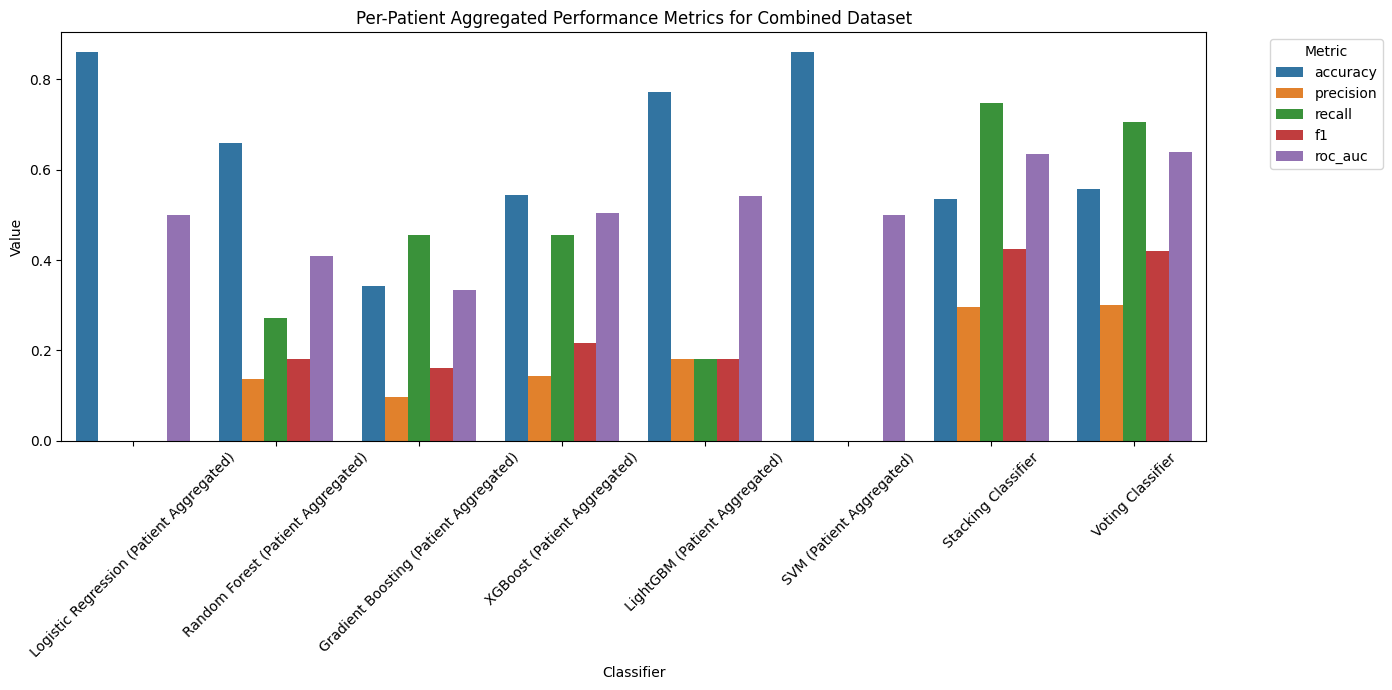

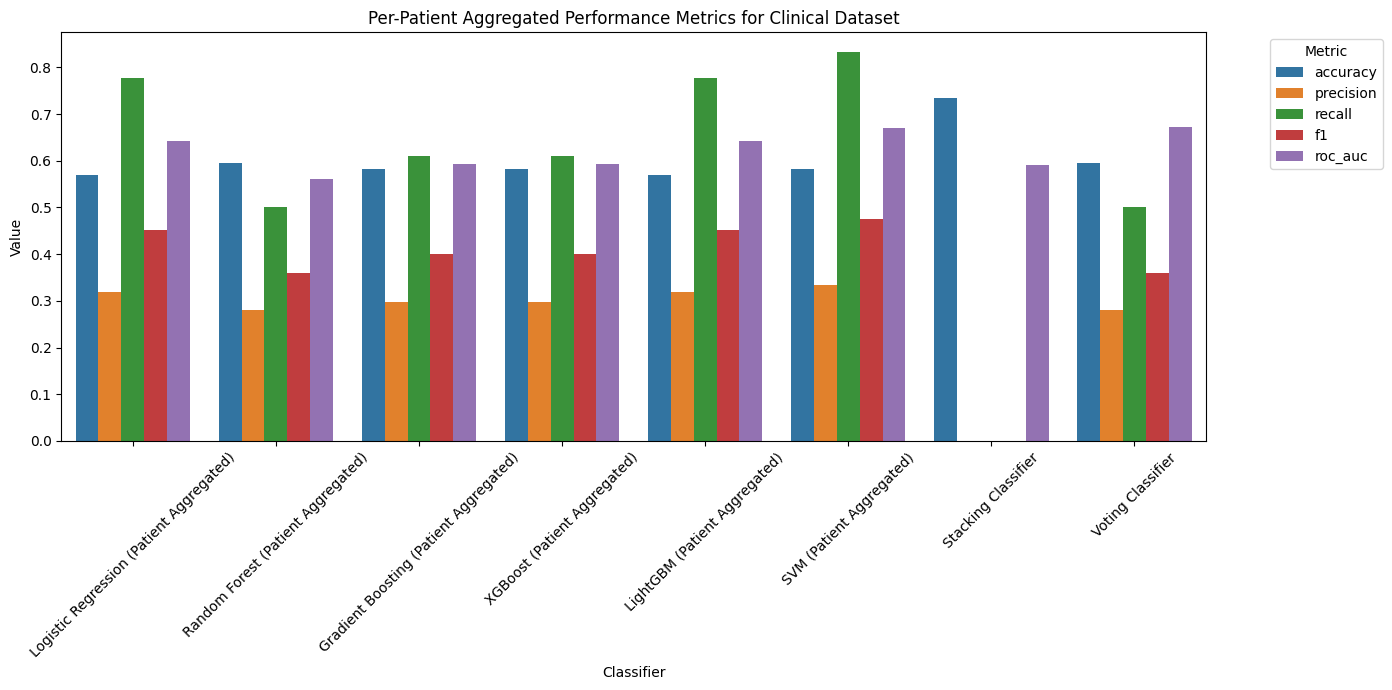

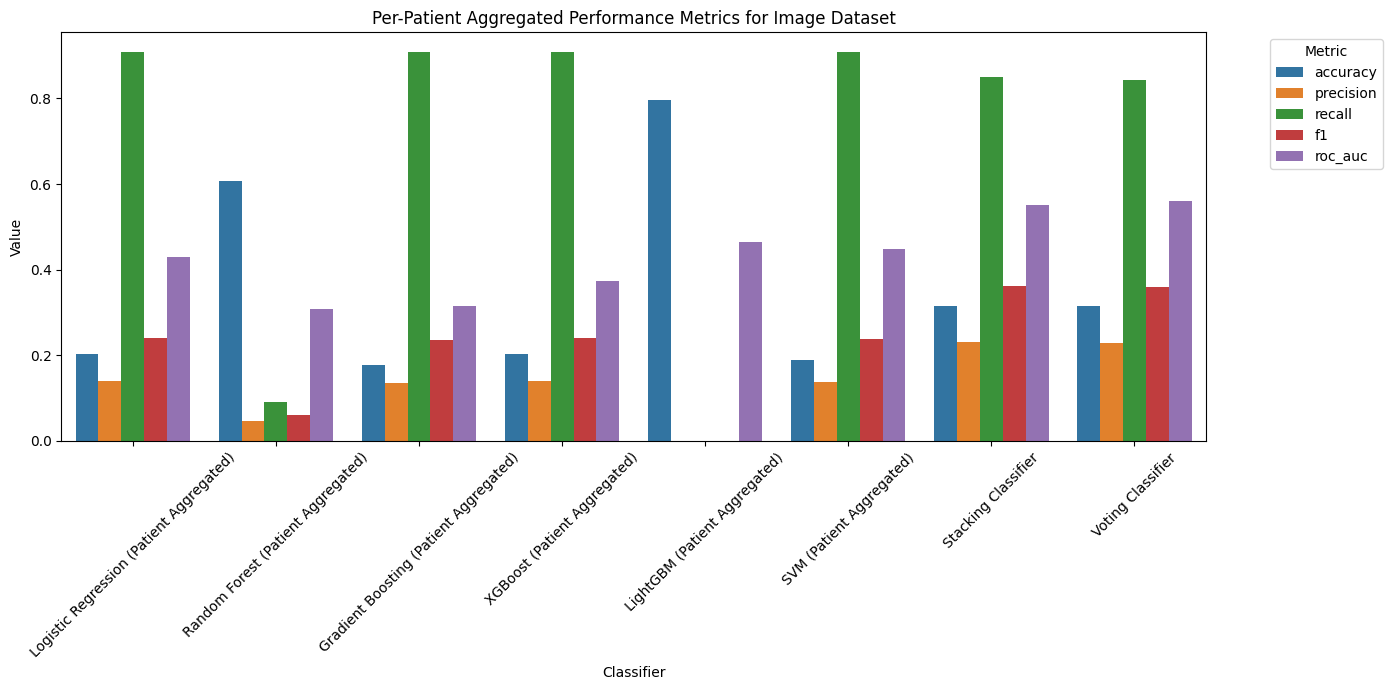

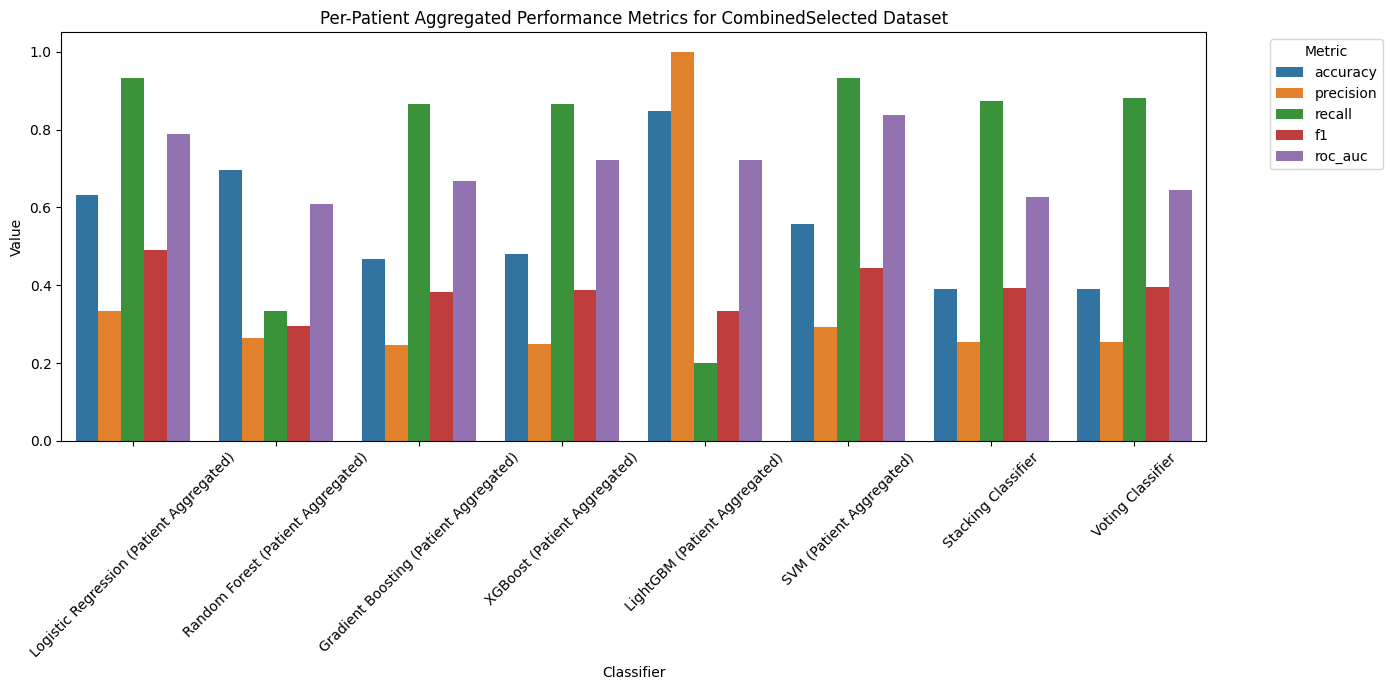

In [158]:
# Visualize Ensemble Classifier Performance

import matplotlib.pyplot as plt
import seaborn as sns

# Update your plotting function to include ensemble classifiers
def plot_metrics_with_ensembles(dataset_name, classifiers_results, ensemble_results):
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    classifier_names = list(classifiers_results.keys()) + list(ensemble_results.keys())
    metric_values = {metric: [] for metric in metrics}
    
    for clf_name in classifier_names:
        if clf_name in classifiers_results:
            results = classifiers_results[clf_name]
        else:
            results = ensemble_results[clf_name]
        for metric in metrics:
            metric_values[metric].append(results[metric])
    
    df_metrics = pd.DataFrame(metric_values, index=classifier_names)
    df_metrics = df_metrics.reset_index().rename(columns={'index': 'Classifier'})
    
    df_melted = df_metrics.melt(id_vars='Classifier', var_name='Metric', value_name='Value')
    
    plt.figure(figsize=(14, 7))
    sns.barplot(x='Classifier', y='Value', hue='Metric', data=df_melted)
    plt.title(f'Per-Patient Aggregated Performance Metrics for {dataset_name} Dataset')
    plt.xticks(rotation=45)
    plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Plot metrics for each dataset
for dataset_name in data_splits.keys():
    classifiers_results = test_results_per_patient[dataset_name]
    ensemble_results = test_results_ensemble.get(dataset_name, {})
    plot_metrics_with_ensembles(dataset_name, classifiers_results, ensemble_results)


Original fused feature dimension: 36
Dimension after interaction features: 666
Reduced dimension after PCA: 337
Random Forest on Refined Early Fusion Features:
Accuracy: 0.36645702306079664
F1 Score: 0.3865205034510759
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.22      0.35      3690
           1       0.25      0.88      0.39      1080

    accuracy                           0.37      4770
   macro avg       0.55      0.55      0.37      4770
weighted avg       0.72      0.37      0.35      4770



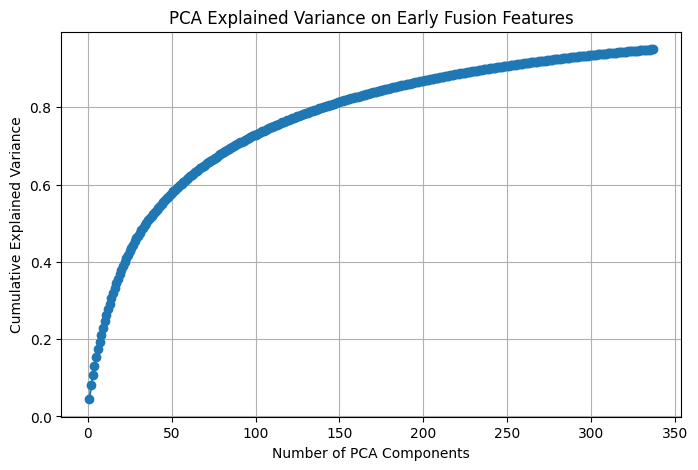

In [159]:
# %% [code]
"""
Expand Early Fusion: Feature Engineering and Modeling

Steps:
1. Retrieve the CombinedSelected dataset and drop any meta columns (like 'patient_id').
2. Generate interaction terms using PolynomialFeatures (interaction-only).
3. Standardize these features.
4. Reduce dimensionality using PCA (retain 95% of the variance).
5. Train a RandomForestClassifier on the refined features and evaluate.
6. Plot cumulative explained variance for PCA components.
"""

import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

# Retrieve CombinedSelected dataset splits
combined_data = data_splits['CombinedSelected']
X_train = combined_data['X_train_full']
y_train = combined_data['y_train_full']
X_test = combined_data['X_test_full']
y_test = combined_data['y_test']

# Drop meta columns (if present) such as 'patient_id'
if 'patient_id' in X_train.columns:
    X_train_fused = X_train.drop(columns=['patient_id'], errors='ignore')
else:
    X_train_fused = X_train.copy()
if 'patient_id' in X_test.columns:
    X_test_fused = X_test.drop(columns=['patient_id'], errors='ignore')
else:
    X_test_fused = X_test.copy()

# Create interaction features using PolynomialFeatures (interaction-only, degree=2)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_fused)
X_test_poly = poly.transform(X_test_fused)

# Standardize polynomial features
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

# Apply PCA to reduce dimensionality while retaining 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_poly_scaled)
X_test_pca = pca.transform(X_test_poly_scaled)

print("Original fused feature dimension:", X_train_fused.shape[1])
print("Dimension after interaction features:", X_train_poly.shape[1])
print("Reduced dimension after PCA:", X_train_pca.shape[1])

# Train a classifier on the refined features (using RandomForestClassifier in this example)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_pca, y_train)
y_pred = rf_model.predict(X_test_pca)

print("Random Forest on Refined Early Fusion Features:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Visualize the cumulative explained variance of the PCA components
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance on Early Fusion Features")
plt.grid(True)
plt.show()


In [160]:
# %% [code]
"""
Enhanced Decision-Level Fusion:
1. Train dedicated models for the Clinical and Image modalities using data_splits.
2. Obtain predicted probabilities for each modality.
3. Reset indices and create DataFrames that combine the test data with patient IDs (using a similar approach you used in other cells).
4. Merge the clinical and image predictions on patient IDs.
5. Combine the prediction probabilities (here, we average them) to make final predictions.
6. Evaluate the final combined (meta) predictions.

This version resets the test DataFrame indices and explicitly creates a 'patient_id' column to ensure that 
the lengths of the predicted probability arrays and patient IDs match.
"""

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler

# ---------------------------
# Clinical modality: Retrieve and prepare test data
# ---------------------------
clinical_data = data_splits['Clinical']
X_test_clinical = clinical_data['X_test_full'].reset_index(drop=True)
y_test_clinical = clinical_data['y_test'].reset_index(drop=True)
patient_ids_test_clinical = clinical_data['patient_ids_test'].reset_index(drop=True)

# Create a DataFrame for clinical test data
df_clinical_test = X_test_clinical.copy()
df_clinical_test['y_true'] = y_test_clinical.values
df_clinical_test['patient_id'] = pd.Series(patient_ids_test_clinical, index=df_clinical_test.index)

# Standardize Clinical features
scaler_clinical = StandardScaler()
X_test_clinical_scaled = scaler_clinical.fit_transform(X_test_clinical)

# ---------------------------
# Image modality: Retrieve and prepare test data
# ---------------------------
image_data = data_splits['Image']
X_test_image = image_data['X_test_full'].reset_index(drop=True)
y_test_image = image_data['y_test'].reset_index(drop=True)
patient_ids_test_image = image_data['patient_ids_test'].reset_index(drop=True)

# Create a DataFrame for image test data
df_image_test = X_test_image.copy()
df_image_test['y_true'] = y_test_image.values
df_image_test['patient_id'] = pd.Series(patient_ids_test_image, index=df_image_test.index)

# Optionally, if your image test set includes augmented data (e.g., an 'aug_id' column),
# you can filter to keep only the original images. For example:
if 'aug_id' in df_image_test.columns:
    df_image_test = df_image_test[df_image_test['aug_id'] == '0'].reset_index(drop=True)

# Standardize Image features
scaler_image = StandardScaler()
X_test_image_scaled = scaler_image.fit_transform(X_test_image)

# ---------------------------
# Train Logistic Regression models on each modality using existing training data
# (Here we only need the test-phase predictions; training is assumed to have been done similarly.)
# ---------------------------
# For Clinical modality: Use the existing training splits from data_splits['Clinical']
model_clinical = LogisticRegression(random_state=42, max_iter=500)
X_train_clinical = clinical_data['X_train_full']
y_train_clinical = clinical_data['y_train_full']
scaler_clinical_train = StandardScaler()
X_train_clinical_scaled = scaler_clinical_train.fit_transform(X_train_clinical)
model_clinical.fit(X_train_clinical_scaled, y_train_clinical)

# Predict probabilities on the clinical test set
pred_prob_clinical_test = model_clinical.predict_proba(X_test_clinical_scaled)[:, 1]
df_clinical_test['pred_prob_clinical'] = pred_prob_clinical_test

# For Image modality: Use the existing training splits from data_splits['Image']
model_image = LogisticRegression(random_state=42, max_iter=500)
X_train_image = image_data['X_train_full']
y_train_image = image_data['y_train_full']
scaler_image_train = StandardScaler()
X_train_image_scaled = scaler_image_train.fit_transform(X_train_image)
model_image.fit(X_train_image_scaled, y_train_image)

# Predict probabilities on the image test set
pred_prob_image_test = model_image.predict_proba(X_test_image_scaled)[:, 1]
df_image_test['pred_prob_image'] = pred_prob_image_test

# ---------------------------
# Merge clinical and image predictions based on patient_id
# ---------------------------
combined_preds_test = pd.merge(
    df_clinical_test[['patient_id', 'pred_prob_clinical']],
    df_image_test[['patient_id', 'pred_prob_image']],
    on='patient_id', how='inner'
)

# ---------------------------
# For evaluation, assume the ground truth labels are taken from the Clinical data test split.
# Align the ground truth with the merged predictions:
# ---------------------------
true_labels_test = df_clinical_test.set_index('patient_id')['y_true']
# Also, set the index for our combined predictions:
combined_preds_test = combined_preds_test.set_index('patient_id')

# ---------------------------
# Decision-Level Fusion:
# Here, as a simple approach, we average the predicted probabilities from both modalities
# and use a threshold of 0.5 to decide the final class.
# ---------------------------
combined_preds_test['avg_prob'] = (
    combined_preds_test['pred_prob_clinical'] + combined_preds_test['pred_prob_image']
) / 2.0

meta_pred = (combined_preds_test['avg_prob'] >= 0.5).astype(int)

print("Decision-Level Fusion Meta-Model Performance (Simple Averaging):")
print("Accuracy:", accuracy_score(true_labels_test.loc[combined_preds_test.index], meta_pred))
print("F1 Score:", f1_score(true_labels_test.loc[combined_preds_test.index], meta_pred))
print("Classification Report:\n", classification_report(true_labels_test.loc[combined_preds_test.index], meta_pred))


Decision-Level Fusion Meta-Model Performance (Simple Averaging):
Accuracy: 0.5120481927710844
F1 Score: 0.5449438202247191
Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.42      0.47       172
           1       0.49      0.61      0.54       160

    accuracy                           0.51       332
   macro avg       0.52      0.52      0.51       332
weighted avg       0.52      0.51      0.51       332



In [161]:
# %% [code]
"""
Decision-Level Fusion for All Classifiers:
For each classifier in your classifiers dictionary, we:
 - Retrieve the test data for the Clinical and Image modalities (resetting the index and adding a 'patient_id' column).
 - Standardize features.
 - Train the classifier on the training split (using data_splits).
 - Predict probabilities on the test sets.
 - Merge the predicted probabilities by patient ID and combine them (using average).
 - Threshold the averaged probability at 0.5 and compute performance metrics.
 
Assumption: The patient-level labels are taken from the Clinical data test set.
"""

import pandas as pd
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Loop over each classifier in your dictionary 'classifiers'
for clf_name, clf in classifiers.items():
    print(f"\n--- Decision-Level Fusion using {clf_name} ---")
    
    # ---------------------------
    # Clinical modality test data setup
    # ---------------------------
    clinical_data = data_splits['Clinical']
    X_test_clinical = clinical_data['X_test_full'].reset_index(drop=True)
    y_test_clinical = clinical_data['y_test'].reset_index(drop=True)
    patient_ids_test_clinical = clinical_data['patient_ids_test'].reset_index(drop=True)
    
    df_clinical_test = X_test_clinical.copy()
    df_clinical_test['y_true'] = y_test_clinical.values
    df_clinical_test['patient_id'] = pd.Series(patient_ids_test_clinical, index=df_clinical_test.index)
    
    scaler_clinical = StandardScaler()
    X_test_clinical_scaled = scaler_clinical.fit_transform(X_test_clinical)
    
    # ---------------------------
    # Image modality test data setup
    # ---------------------------
    image_data = data_splits['Image']
    X_test_image = image_data['X_test_full'].reset_index(drop=True)
    y_test_image = image_data['y_test'].reset_index(drop=True)
    patient_ids_test_image = image_data['patient_ids_test'].reset_index(drop=True)
    
    df_image_test = X_test_image.copy()
    df_image_test['y_true'] = y_test_image.values
    df_image_test['patient_id'] = pd.Series(patient_ids_test_image, index=df_image_test.index)
    
    # If an augmented flag exists (e.g., 'aug_id'), filter for originals
    if 'aug_id' in df_image_test.columns:
        df_image_test = df_image_test[df_image_test['aug_id'] == '0'].reset_index(drop=True)
    
    scaler_image = StandardScaler()
    X_test_image_scaled = scaler_image.fit_transform(X_test_image)
    
    # ---------------------------
    # Train and predict on the Clinical modality training data
    # ---------------------------
    # For Clinical, use the training splits from data_splits['Clinical']
    X_train_clinical = clinical_data['X_train_full']
    y_train_clinical = clinical_data['y_train_full']
    scaler_clinical_train = StandardScaler()
    X_train_clinical_scaled = scaler_clinical_train.fit_transform(X_train_clinical)
    
    clf_clinical = clone(clf)
    clf_clinical.fit(X_train_clinical_scaled, y_train_clinical)
    # Predict probabilities on test set for Clinical modality
    pred_prob_clinical_test = clf_clinical.predict_proba(X_test_clinical_scaled)[:, 1]
    df_clinical_test['pred_prob'] = pred_prob_clinical_test
    
    # ---------------------------
    # Train and predict on the Image modality training data
    # ---------------------------
    image_train = image_data['X_train_full']
    y_train_image = image_data['y_train_full']
    scaler_image_train = StandardScaler()
    X_train_image_scaled = scaler_image_train.fit_transform(image_train)
    
    clf_image = clone(clf)
    clf_image.fit(X_train_image_scaled, y_train_image)
    pred_prob_image_test = clf_image.predict_proba(X_test_image_scaled)[:, 1]
    df_image_test['pred_prob'] = pred_prob_image_test
    
    # ---------------------------
    # Merge the predictions based on patient_id
    # ---------------------------
    merged_preds = pd.merge(
        df_clinical_test[['patient_id', 'pred_prob']],
        df_image_test[['patient_id', 'pred_prob']],
        on='patient_id',
        how='inner',
        suffixes=('_clinical', '_image')
    )
    
    # ---------------------------
    # Combine probabilities (simple averaging) and make final prediction
    # ---------------------------
    merged_preds['avg_prob'] = (merged_preds['pred_prob_clinical'] + merged_preds['pred_prob_image']) / 2.0
    final_pred = (merged_preds['avg_prob'] >= 0.5).astype(int)
    
    # ---------------------------
    # Evaluation (using ground-truth from Clinical test set)
    # ---------------------------
    # Set the index of ground truth by patient_id (taken from df_clinical_test)
    true_labels = df_clinical_test.set_index('patient_id')['y_true']
    merged_preds = merged_preds.set_index('patient_id')
    
    acc = accuracy_score(true_labels.loc[merged_preds.index], final_pred)
    f1 = f1_score(true_labels.loc[merged_preds.index], final_pred)
    clf_report = classification_report(true_labels.loc[merged_preds.index], final_pred)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Classification Report:")
    print(clf_report)



--- Decision-Level Fusion using Logistic Regression ---
Accuracy: 0.5151
F1 Score: 0.5490
Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.42      0.48       172
           1       0.50      0.61      0.55       160

    accuracy                           0.52       332
   macro avg       0.52      0.52      0.51       332
weighted avg       0.52      0.52      0.51       332


--- Decision-Level Fusion using Random Forest ---
Accuracy: 0.6175
F1 Score: 0.6667
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.45      0.55       172
           1       0.57      0.79      0.67       160

    accuracy                           0.62       332
   macro avg       0.64      0.62      0.61       332
weighted avg       0.64      0.62      0.61       332


--- Decision-Level Fusion using Gradient Boosting ---
Accuracy: 0.5723
F1 Score: 0.5749
Classification Report:
            